In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv("api_data_aadhar_enrolment_0_500000.csv")
df2 = pd.read_csv("api_data_aadhar_enrolment_500000_1000000.csv")
df3 = pd.read_csv("api_data_aadhar_enrolment_1000000_1006029.csv")

In [3]:
df1.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [4]:
df2.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,26-10-2025,Andhra Pradesh,Nalgonda,508004,0,1,0
1,26-10-2025,Andhra Pradesh,Nalgonda,508238,1,0,0
2,26-10-2025,Andhra Pradesh,Nalgonda,508278,1,0,0
3,26-10-2025,Andhra Pradesh,Nandyal,518432,0,1,0
4,26-10-2025,Andhra Pradesh,Nandyal,518543,1,0,0


In [5]:
df3.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,31-12-2025,Karnataka,Bidar,585330,2,3,0
1,31-12-2025,Karnataka,Bidar,585402,6,0,0
2,31-12-2025,Karnataka,Bidar,585413,1,0,0
3,31-12-2025,Karnataka,Bidar,585418,1,2,0
4,31-12-2025,Karnataka,Bidar,585421,4,3,0


In [6]:
df = pd.concat([df1, df2, df3], ignore_index=True)
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [7]:
df["state"].value_counts()

state
Uttar Pradesh                                   110369
Tamil Nadu                                       92552
Maharashtra                                      77191
West Bengal                                      76519
Karnataka                                        70198
Andhra Pradesh                                   65658
Bihar                                            60567
Rajasthan                                        56159
Madhya Pradesh                                   50225
Gujarat                                          46624
Odisha                                           43691
Telangana                                        42774
Kerala                                           39145
Assam                                            31827
Jharkhand                                        23218
Punjab                                           20439
Chhattisgarh                                     18550
Haryana                                          15997
Jamm

In [8]:
df["state"].unique()

array(['Meghalaya', 'Karnataka', 'Uttar Pradesh', 'Bihar', 'Maharashtra',
       'Haryana', 'Rajasthan', 'Punjab', 'Delhi', 'Madhya Pradesh',
       'West Bengal', 'Assam', 'Uttarakhand', 'Gujarat', 'Andhra Pradesh',
       'Tamil Nadu', 'Chhattisgarh', 'Jharkhand', 'Nagaland', 'Manipur',
       'Telangana', 'Tripura', 'Mizoram', 'Jammu and Kashmir',
       'Chandigarh', 'Sikkim', 'Odisha', 'Kerala',
       'The Dadra And Nagar Haveli And Daman And Diu',
       'Arunachal Pradesh', 'Himachal Pradesh', 'Goa',
       'Jammu And Kashmir', 'Dadra and Nagar Haveli and Daman and Diu',
       'Ladakh', 'Andaman and Nicobar Islands', 'Orissa', 'Pondicherry',
       'Puducherry', 'Lakshadweep', 'Andaman & Nicobar Islands',
       'Dadra & Nagar Haveli', 'Dadra and Nagar Haveli', 'Daman and Diu',
       'WEST BENGAL', 'Jammu & Kashmir', 'West  Bengal', '100000',
       'Daman & Diu', 'West Bangal', 'Westbengal', 'West bengal',
       'andhra pradesh', 'ODISHA', 'WESTBENGAL'], dtype=object)

In [9]:
df["state"].nunique()

55

In [10]:
sorted_states = sorted(df["state"].astype(str).unique())
sorted_states

['100000',
 'Andaman & Nicobar Islands',
 'Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra & Nagar Haveli',
 'Dadra and Nagar Haveli',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Daman & Diu',
 'Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu & Kashmir',
 'Jammu And Kashmir',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'ODISHA',
 'Odisha',
 'Orissa',
 'Pondicherry',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'The Dadra And Nagar Haveli And Daman And Diu',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'WEST BENGAL',
 'WESTBENGAL',
 'West  Bengal',
 'West Bangal',
 'West Bengal',
 'West bengal',
 'Westbengal',
 'andhra pradesh']

In [11]:
df["state_norm"] = (df["state"].astype(str).str.strip().str.lower().str.replace(r"\s+", " ", regex=True))

In [12]:
state_clean_map = {
    "andaman & nicobar islands": "Andaman & Nicobar Islands",
    "andaman and nicobar islands": "Andaman & Nicobar Islands",
    "andhra pradesh": "Andhra Pradesh",
    "arunachal pradesh": "Arunachal Pradesh",
    "assam": "Assam",
    "bihar": "Bihar",
    "chandigarh": "Chandigarh",
    "chhattisgarh": "Chhattisgarh",
    "dadra & nagar haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra and nagar haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "daman & diu": "Dadra & Nagar Haveli and Daman & Diu",
    "daman and diu": "Dadra & Nagar Haveli and Daman & Diu",
    "the dadra and nagar haveli and daman and diu": "Dadra & Nagar Haveli and Daman & Diu",
    "The Dadra And Nagar Haveli And Daman And Diu": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra and nagar haveli and daman and diu": "Dadra & Nagar Haveli and Daman & Diu",
    "delhi": "Delhi",
    "goa": "Goa",
    "gujarat": "Gujarat",
    "haryana": "Haryana",
    "himachal pradesh": "Himachal Pradesh",
    "jammu & kashmir": "Jammu & Kashmir",
    "jammu and kashmir": "Jammu & Kashmir",
    "jharkhand": "Jharkhand",
    "karnataka": "Karnataka",
    "kerala": "Kerala",
    "ladakh": "Ladakh",
    "lakshadweep": "Lakshadweep",
    "madhya pradesh": "Madhya Pradesh",
    "maharashtra": "Maharashtra",
    "manipur": "Manipur",
    "meghalaya": "Meghalaya",
    "mizoram": "Mizoram",
    "nagaland": "Nagaland",
    "odisha": "Odisha",
    "orissa": "Odisha",
    "puducherry": "Puducherry",
    "pondicherry": "Puducherry",
    "punjab": "Punjab",
    "rajasthan": "Rajasthan",
    "sikkim": "Sikkim",
    "tamil nadu": "Tamil Nadu",
    "telangana": "Telangana",
    "tripura": "Tripura",
    "uttar pradesh": "Uttar Pradesh",
    "uttarakhand": "Uttarakhand",
    "west bengal": "West Bengal",
    "west  bengal": "West Bengal",
    "westbengal": "West Bengal",
    "west bangal": "West Bengal",
    "100000": "Unknown"
}

In [13]:
df["state_clean"] = df["state_norm"].replace(state_clean_map)

In [14]:
df["state_clean"] = (df["state"].astype(str).str.strip().str.lower())

In [15]:
df["state_clean"] = df["state_clean"].replace(state_clean_map)

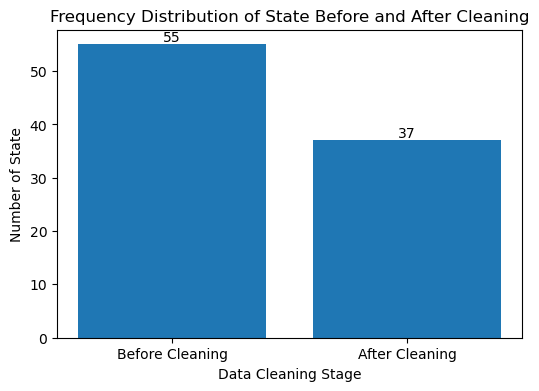

In [16]:
labels = ["Before Cleaning", "After Cleaning"]
district_counts = [55, 37]
plt.figure(figsize=(6,4))
bars = plt.bar(labels, district_counts)
plt.xlabel("Data Cleaning Stage")
plt.ylabel("Number of State")
plt.title("Frequency Distribution of State Before and After Cleaning")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom')
plt.show()

In [17]:
df["state_clean"].nunique()

37

In [18]:
df["district"].nunique()

985

In [19]:
df["district"].unique()

array(['East Khasi Hills', 'Bengaluru Urban', 'Kanpur Nagar', 'Aligarh',
       'Sitamarhi', 'Bahraich', 'Firozabad', 'Purbi Champaran',
       'Maharajganj', 'Aurangabad', 'Ghaziabad', 'Faridabad', 'Madhubani',
       'Sikar', 'Bhagalpur', 'Amritsar', 'Gurugram',
       'Gautam Buddha Nagar', 'West Delhi', 'Bhind', 'Gwalior', 'Katni',
       'Coochbehar', 'Lucknow', 'Dinajpur Uttar', 'Marigaon', 'Kokrajhar',
       'Agra', 'Haridwar', 'Nagaon', 'Parbhani', 'West Khasi Hills',
       'North West Delhi', 'West Jaintia Hills', 'Unnao', 'Saharanpur',
       'Dibrugarh', 'Udalguri', 'Chirang', 'Kamrup', 'Dhubri', 'Jaunpur',
       'Thane', 'Dhemaji', 'Banas Kantha', 'Tinsukia', 'Spsr Nellore',
       'Barpeta', 'Sonitpur', 'Baksa', 'Ludhiana', 'Patan', 'Kanchipuram',
       'Patna', 'Lakhimpur', 'Bongaigaon', 'Vadodara', 'Nainital',
       'Dehradun', 'Hojai', 'Dohad', 'Morbi', 'Raipur', 'Gorakhpur',
       'Bulandshahr', 'Mathura', 'Pashchim Champaran', 'Bijapur',
       'Deoghar', 'Muzaf

In [20]:
df["district_norm"] = (
    df["district"].astype(str).str.strip().str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"[^\w\s]", "", regex=True))

In [21]:
df

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,state_norm,state_clean,district_norm
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37,meghalaya,Meghalaya,east khasi hills
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39,karnataka,Karnataka,bengaluru urban
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,uttar pradesh,Uttar Pradesh,kanpur nagar
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15,uttar pradesh,Uttar Pradesh,aligarh
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21,karnataka,Karnataka,bengaluru urban
...,...,...,...,...,...,...,...,...,...,...
1006024,31-12-2025,West Bengal,West Midnapore,721149,2,0,0,west bengal,West Bengal,west midnapore
1006025,31-12-2025,West Bengal,West Midnapore,721150,2,2,0,west bengal,West Bengal,west midnapore
1006026,31-12-2025,West Bengal,West Midnapore,721305,0,1,0,west bengal,West Bengal,west midnapore
1006027,31-12-2025,West Bengal,West Midnapore,721504,1,0,0,west bengal,West Bengal,west midnapore


In [22]:
district_clean_map = {
 "100000": "Unknown",
 "24 paraganas north": "North 24 Parganas",
 "24 paraganas south": "South 24 Parganas",
 "adilabad": "Adilabad",
 "agar malwa": "Agar Malwa",
 "agra": "Agra",
 "ahilyanagar": "Ahilyanagar",
 "ahmadabad": "Ahmedabad",
 "ahmadnagar": "Ahmadnagar",
 "ahmed nagar": "Ahmed Nagar",
 "ahmedabad": "Ahmedabad",
 "ahmednagar": "Ahilyanagar",
 "aizawl": "Aizawl",
 "ajmer": "Ajmer",
 "akola": "Akola",
 "alappuzha": "Alappuzha",
 "aligarh": "Aligarh",
 "alipurduar": "Alipurduar",
 "alirajpur": "Alirajpur",
 "allahabad": "Prayagraj",
 "alluri sitharama raju": "Alluri Sitharama Raju",
 "almora": "Almora",
 "alwar": "Alwar",
 "ambala": "Ambala",
 "ambedkar nagar": "Ambedkar Nagar",
 "amethi": "Amethi",
 "amravati": "Amravati",
 "amreli": "Amreli",
 "amritsar": "Amritsar",
 "amroha": "Amroha",
 "anakapalli": "Anakapalli",
 "anand": "Anand",
 "anantapur": "Anantapur",
 "ananthapur": "Ananthapur",
 "ananthapuramu": "Ananthapuramu",
 "anantnag": "Anantnag",
 "andamans": "Andamans",
 "angul": "Angul",
 "anjaw": "Anjaw",
 "annamayya": "Annamayya",
 "anugal": "Angul",
 "anugul": "Angul",
 "anuppur": "Anuppur",
 "araria": "Araria",
 "ariyalur": "Ariyalur",
 "arvalli": "Arvalli",
 "arwal": "Arwal",
 "ashok nagar": "Ashok Nagar",
 "ashoknagar": "Ashoknagar",
 "auraiya": "Auraiya",
 "aurangabad": "Aurangabad",
 "aurangabad(bh)": "Aurangabad",
 "ayodhya": "Ayodhya",
 "azamgarh": "Azamgarh",
 "badgam": "Badgam",
 "bagalkot": "Bagalkot",
 "bagalkot *": "Bagalkot",
 "bageshwar": "Bageshwar",
 "baghpat": "Baghpat",
 "bagpat": "Bagpat",
 "bahraich": "Bahraich",
 "bajali": "Bajali",
 "baksa": "Baksa",
 "balaghat": "Balaghat",
 "balangir": "Balangir",
 "baleshwar": "Baleshwar",
 "baleswar": "Baleswar",
 "ballari": "Ballari",
 "ballia": "Ballia",
 "balod": "Balod",
 "baloda bazar": "Baloda Bazar",
 "balotra": "Balotra",
 "balrampur": "Balrampur",
 "banas kantha": "Banas Kantha",
 "banaskantha": "Banaskantha",
 "banda": "Banda",
 "bandipore": "Bandipore",
 "bandipur": "Bandipur",
 "bangalore": "Bengaluru Urban",
 "bangalore rural": "Bengaluru Rural",
 "banka": "Banka",
 "bankura": "Bankura",
 "banswara": "Banswara",
 "bapatla": "Bapatla",
 "bara banki": "Bara Banki",
 "barabanki": "Barabanki",
 "baramula": "Baramulla",
 "baran": "Baran",
 "barddhaman": "Barddhaman",
 "bardez": "Bardez",
 "bardhaman": "Bardhaman",
 "bareilly": "Bareilly",
 "bargarh": "Bargarh",
 "barmer": "Barmer",
 "barnala": "Barnala",
 "barpeta": "Barpeta",
 "barwani": "Barwani",
 "bastar": "Bastar",
 "basti": "Basti",
 "bathinda": "Bathinda",
 "baudh": "Baudh",
 "beawar": "Beawar",
 "beed": "Beed",
 "begusarai": "Begusarai",
 "belagavi": "Belagavi",
 "belgaum": "Belagavi",
 "bellary": "Ballari",
 "bemetara": "Bemetara",
 "bengaluru": "Bengaluru Urban",
 "bengaluru rural": "Bengaluru Rural",
 "bengaluru south": "Bengaluru Urban",
 "bengaluru urban": "Bengaluru Urban",
 "betul": "Betul",
 "bhabua": "Bhabua",
 "bhadohi": "Bhadohi",
 "bhadradri kothagudem": "Bhadradri Kothagudem",
 "bhadrak": "Bhadrak",
 "bhagalpur": "Bhagalpur",
 "bhandara": "Bhandara",
 "bharatpur": "Bharatpur",
 "bharuch": "Bharuch",
 "bhavnagar": "Bhavnagar",
 "bhilwara": "Bhilwara",
 "bhind": "Bhind",
 "bhiwani": "Bhiwani",
 "bhojpur": "Bhojpur",
 "bhopal": "Bhopal",
 "bid": "Bid",
 "bidar": "Bidar",
 "bijapur": "Bijapur",
 "bijapur(kar)": "Vijayapura",
 "bijnor": "Bijnor",
 "bikaner": "Bikaner",
 "bilaspur": "Bilaspur",
 "birbhum": "Birbhum",
 "bishnupur": "Bishnupur",
 "biswanath": "Biswanath",
 "bokaro": "Bokaro",
 "bokaro *": "Bokaro",
 "bongaigaon": "Bongaigaon",
 "botad": "Botad",
 "boudh": "Boudh",
 "budaun": "Budaun",
 "budgam": "Budgam",
 "bulandshahar": "Bulandshahr",
 "bulandshahr": "Bulandshahr",
 "buldana": "Buldana",
 "buldhana": "Buldhana",
 "bundi": "Bundi",
 "burdwan": "Burdwan",
 "burhanpur": "Burhanpur",
 "buxar": "Buxar",
 "cachar": "Cachar",
 "central delhi": "Central Delhi",
 "chamarajanagar": "Chamarajanagar",
 "chamarajanagar *": "Chamarajanagar",
 "chamba": "Chamba",
 "chamoli": "Chamoli",
 "champawat": "Champawat",
 "champhai": "Champhai",
 "chamrajanagar": "Chamarajanagar",
 "chamrajnagar": "Chamarajanagar",
 "chandauli": "Chandauli",
 "chandel": "Chandel",
 "chandigarh": "Chandigarh",
 "chandrapur": "Chandrapur",
 "changlang": "Changlang",
 "charaideo": "Charaideo",
 "charkhi dadri": "Charkhi Dadri",
 "chatra": "Chatra",
 "chatrapati sambhaji nagar": "Chatrapati Sambhaji Nagar",
 "chengalpattu": "Chengalpattu",
 "chennai": "Chennai",
 "chhatarpur": "Chhatarpur",
 "chhatrapati sambhajinagar": "Chhatrapati Sambhajinagar",
 "chhindwara": "Chhindwara",
 "chhotaudepur": "Chhotaudepur",
 "chickmagalur": "Chikkamagaluru",
 "chikkaballapur": "Chikkaballapur",
 "chikkamagaluru": "Chikkamagaluru",
 "chikmagalur": "Chikkamagaluru",
 "chirang": "Chirang",
 "chitradurga": "Chitradurga",
 "chitrakoot": "Chitrakoot",
 "chittaurgarh": "Chittaurgarh",
 "chittoor": "Chittoor",
 "chittorgarh": "Chittorgarh",
 "chumukedima": "Chumukedima",
 "churachandpur": "Churachandpur",
 "churu": "Churu",
 "coimbatore": "Coimbatore",
 "cooch behar": "Cooch Behar",
 "coochbehar": "Cooch Behar",
 "cuddalore": "Cuddalore",
 "cuddapah": "Y.S.R.",
 "cuttack": "Cuttack",
 "dadra & nagar haveli": "Dadra & Nagar Haveli",
 "dadra and nagar haveli": "Dadra & Nagar Haveli",
 "dahod": "Dahod",
 "dakshin bastar dantewada": "Dantewada",
 "dakshin dinajpur": "Dakshin Dinajpur",
 "dakshina kannada": "Dakshina Kannada",
 "daman": "Daman",
 "damoh": "Damoh",
 "dang": "Dang",
 "dantewada": "Dantewada",
 "darbhanga": "Darbhanga",
 "darjeeling": "Darjeeling",
 "darjiling": "Darjeeling",
 "darrang": "Darrang",
 "datia": "Datia",
 "dausa": "Dausa",
 "davanagere": "Davanagere",
 "davangere": "Davanagere",
 "debagarh": "Debagarh",
 "deeg": "Deeg",
 "dehradun": "Dehradun",
 "deoghar": "Deoghar",
 "deoria": "Deoria",
 "devbhumi dwarka": "Devbhumi Dwarka",
 "dewas": "Dewas",
 "dhalai": "Dhalai",
 "dhalai *": "Dhalai",
 "dhamtari": "Dhamtari",
 "dhanbad": "Dhanbad",
 "dhar": "Dhar",
 "dharashiv": "Dharashiv",
 "dharmapuri": "Dharmapuri",
 "dharwad": "Dharwad",
 "dhaulpur": "Dholpur",
 "dhemaji": "Dhemaji",
 "dhenkanal": "Dhenkanal",
 "dholpur": "Dholpur",
 "dhubri": "Dhubri",
 "dhule": "Dhule",
 "dibang valley": "Dibang Valley",
 "dibrugarh": "Dibrugarh",
 "didwana-kuchaman": "Didwana-Kuchaman",
 "dima hasao": "Dima Hasao",
 "dimapur": "Dimapur",
 "dinajpur dakshin": "Dinajpur Dakshin",
 "dinajpur uttar": "Dinajpur Uttar",
 "dindigul": "Dindigul",
 "dindori": "Dindori",
 "diu": "Diu",
 "doda": "Doda",
 "dohad": "Dohad",
 "dr. b. r. ambedkar konaseema": "Dr. B. R. Ambedkar Konaseema",
 "dumka": "Dumka",
 "dungarpur": "Dungarpur",
 "durg": "Durg",
 "east": "East",
 "east champaran": "East Champaran",
 "east delhi": "East Delhi",
 "east garo hills": "East Garo Hills",
 "east godavari": "East Godavari",
 "east jaintia hills": "East Jaintia Hills",
 "east kameng": "East Kameng",
 "east khasi hills": "East Khasi Hills",
 "east midnapore": "Purba Medinipur",
 "east midnapur": "Purba Medinipur",
 "east nimar": "East Nimar",
 "east siang": "East Siang",
 "east sikkim": "East Sikkim",
 "east singhbhum": "East Singhbhum",
 "east singhbum": "East Singhbum",
 "eastern west khasi hills": "Eastern West Khasi Hills",
 "eluru": "Eluru",
 "ernakulam": "Ernakulam",
 "erode": "Erode",
 "etah": "Etah",
 "etawah": "Etawah",
 "faizabad": "Ayodhya",
 "faridabad": "Faridabad",
 "faridkot": "Faridkot",
 "farrukhabad": "Farrukhabad",
 "fatehabad": "Fatehabad",
 "fatehgarh sahib": "Fatehgarh Sahib",
 "fatehpur": "Fatehpur",
 "fazilka": "Fazilka",
 "ferozepur": "Ferozepur",
 "firozabad": "Firozabad",
 "firozpur": "Ferozepur",
 "gadag": "Gadag",
 "gadag *": "Gadag",
 "gadchiroli": "Gadchiroli",
 "gajapati": "Gajapati",
 "ganderbal": "Ganderbal",
 "gandhinagar": "Gandhinagar",
 "ganganagar": "Ganganagar",
 "ganjam": "Ganjam",
 "garhwa": "Garhwa",
 "garhwa *": "Garhwa",
 "garhwal": "Garhwal",
 "gariyaband": "Gariyaband",
 "gaurela-pendra-marwahi": "Gaurela-Pendra-Marwahi",
 "gaurella pendra marwahi": "Gaurella Pendra Marwahi",
 "gautam buddha nagar": "Gautam Buddha Nagar",
 "gaya": "Gaya",
 "ghaziabad": "Ghaziabad",
 "ghazipur": "Ghazipur",
 "gir somnath": "Gir Somnath",
 "giridih": "Giridih",
 "goalpara": "Goalpara",
 "godda": "Godda",
 "golaghat": "Golaghat",
 "gomati": "Gomati",
 "gonda": "Gonda",
 "gondia": "Gondia",
 "gondiya": "Gondiya",
 "gondiya *": "Gondiya",
 "gopalganj": "Gopalganj",
 "gorakhpur": "Gorakhpur",
 "gulbarga": "Kalaburagi",
 "gumla": "Gumla",
 "guna": "Guna",
 "guntur": "Guntur",
 "gurdaspur": "Gurdaspur",
 "gurgaon": "Gurugram",
 "gurugram": "Gurugram",
 "gwalior": "Gwalior",
 "hailakandi": "Hailakandi",
 "hamirpur": "Hamirpur",
 "hanumakonda": "Hanumakonda",
 "hanumangarh": "Hanumangarh",
 "haora": "Howrah",
 "hapur": "Hapur",
 "harda": "Harda",
 "harda *": "Harda",
 "hardoi": "Hardoi",
 "hardwar": "Hardwar",
 "haridwar": "Haridwar",
 "hasan": "Hasan",
 "hassan": "Hassan",
 "hathras": "Hathras",
 "haveri": "Haveri",
 "haveri *": "Haveri",
 "hawrah": "Howrah",
 "hazaribag": "Hazaribag",
 "hazaribagh": "Hazaribagh",
 "hingoli": "Hingoli",
 "hingoli *": "Hingoli",
 "hisar": "Hisar",
 "hnahthial": "Hnahthial",
 "hojai": "Hojai",
 "hooghiy": "Hooghly",
 "hooghly": "Hooghly",
 "hoshangabad": "Hoshangabad",
 "hoshiarpur": "Hoshiarpur",
 "howrah": "Howrah",
 "hugli": "Hooghly",
 "hyderabad": "Hyderabad",
 "idukki": "Idukki",
 "imphal east": "Imphal East",
 "imphal west": "Imphal West",
 "indore": "Indore",
 "jabalpur": "Jabalpur",
 "jagatsinghapur": "Jagatsinghapur",
 "jagatsinghpur": "Jagatsinghpur",
 "jagitial": "Jagitial",
 "jaintia hills": "Jaintia Hills",
 "jaipur": "Jaipur",
 "jaisalmer": "Jaisalmer",
 "jajapur": "Jajpur",
 "jajpur": "Jajpur",
 "jalandhar": "Jalandhar",
 "jalaun": "Jalaun",
 "jalgaon": "Jalgaon",
 "jalna": "Jalna",
 "jalor": "Jalor",
 "jalore": "Jalore",
 "jalpaiguri": "Jalpaiguri",
 "jammu": "Jammu",
 "jamnagar": "Jamnagar",
 "jamtara": "Jamtara",
 "jamui": "Jamui",
 "jangaon": "Jangaon",
 "jangoan": "Jangoan",
 "janjgir - champa": "Janjgir-Champa",
 "janjgir champa": "Janjgir-Champa",
 "janjgir-champa": "Janjgir-Champa",
 "jashpur": "Jashpur",
 "jaunpur": "Jaunpur",
 "jayashankar bhupalpally": "Jayashankar Bhupalpally",
 "jehanabad": "Jehanabad",
 "jhabua": "Jhabua",
 "jhajjar": "Jhajjar",
 "jhajjar *": "Jhajjar",
 "jhalawar": "Jhalawar",
 "jhansi": "Jhansi",
 "jhargram": "Jhargram",
 "jharsuguda": "Jharsuguda",
 "jhunjhunu": "Jhunjhunu",
 "jhunjhunun": "Jhunjhunun",
 "jind": "Jind",
 "jiribam": "Jiribam",
 "jodhpur": "Jodhpur",
 "jogulamba gadwal": "Jogulamba Gadwal",
 "jorhat": "Jorhat",
 "junagadh": "Junagadh",
 "jyotiba phule nagar": "Amroha",
 "k.v. rangareddy": "Rangareddy",
 "k.v.rangareddy": "Rangareddy",
 "kabeerdham": "Kabeerdham",
 "kachchh": "Kachchh",
 "kaimur (bhabua)": "Kaimur (Bhabua)",
 "kaithal": "Kaithal",
 "kakching": "Kakching",
 "kakinada": "Kakinada",
 "kalaburagi": "Kalaburagi",
 "kalahandi": "Kalahandi",
 "kalimpong": "Kalimpong",
 "kallakurichi": "Kallakurichi",
 "kamareddy": "Kamareddy",
 "kamle": "Kamle",
 "kamrup": "Kamrup",
 "kamrup metro": "Kamrup Metro",
 "kancheepuram": "Kanchipuram",
 "kanchipuram": "Kanchipuram",
 "kandhamal": "Kandhamal",
 "kangra": "Kangra",
 "kanker": "Kanker",
 "kannauj": "Kannauj",
 "kanniyakumari": "Kanniyakumari",
 "kannur": "Kannur",
 "kanpur dehat": "Kanpur Dehat",
 "kanpur nagar": "Kanpur Nagar",
 "kanyakumari": "Kanyakumari",
 "kapurthala": "Kapurthala",
 "karaikal": "Karaikal",
 "karauli": "Karauli",
 "karbi anglong": "Karbi Anglong",
 "kargil": "Kargil",
 "karim nagar": "Karim Nagar",
 "karimganj": "Karimganj",
 "karimnagar": "Karimnagar",
 "karnal": "Karnal",
 "karur": "Karur",
 "kasaragod": "Kasaragod",
 "kasargod": "Kasargod",
 "kasganj": "Kasganj",
 "kathua": "Kathua",
 "katihar": "Katihar",
 "katni": "Katni",
 "kaushambi": "Kaushambi",
 "kawardha": "Kawardha",
 "kendrapara": "Kendrapara",
 "kendrapara *": "Kendrapara",
 "kendujhar": "Kendujhar",
 "khagaria": "Khagaria",
 "khairagarh chhuikhadan gandai": "Khairagarh Chhuikhadan Gandai",
 "khammam": "Khammam",
 "khandwa": "Khandwa",
 "khargone": "Khargone",
 "khawzawl": "Khawzawl",
 "kheda": "Kheda",
 "kheri": "Lakhimpur Kheri",
 "khorda": "Khorda",
 "khordha": "Khordha",
 "khowai": "Khowai",
 "khunti": "Khunti",
 "kinnaur": "Kinnaur",
 "kiphire": "Kiphire",
 "kishanganj": "Kishanganj",
 "kishtwar": "Kishtwar",
 "koch bihar": "Cooch Behar",
 "kodagu": "Kodagu",
 "kodarma": "Kodarma",
 "koderma": "Kodarma",
 "kohima": "Kohima",
 "kokrajhar": "Kokrajhar",
 "kolar": "Kolar",
 "kolasib": "Kolasib",
 "kolhapur": "Kolhapur",
 "kolkata": "Kolkata",
 "kollam": "Kollam",
 "komaram bheem": "Komaram Bheem",
 "kondagaon": "Kondagaon",
 "koppal": "Koppal",
 "koraput": "Koraput",
 "korba": "Korba",
 "koriya": "Koriya",
 "kota": "Kota",
 "kottayam": "Kottayam",
 "kozhikode": "Kozhikode",
 "kra daadi": "Kra Daadi",
 "krishna": "Krishna",
 "krishnagiri": "Krishnagiri",
 "kulgam": "Kulgam",
 "kullu": "Kullu",
 "kupwara": "Kupwara",
 "kurnool": "Kurnool",
 "kurukshetra": "Kurukshetra",
 "kurung kumey": "Kurung Kumey",
 "kushi nagar": "Kushi Nagar",
 "kushinagar": "Kushinagar",
 "kushinagar *": "Kushinagar",
 "lahaul and spiti": "Lahaul And Spiti",
 "lahul & spiti": "Lahul & Spiti",
 "lahul and spiti": "Lahul And Spiti",
 "lakhimpur": "Lakhimpur Kheri",
 "lakhisarai": "Lakhisarai",
 "lakshadweep": "Lakshadweep",
 "lalitpur": "Lalitpur",
 "latehar": "Latehar",
 "latur": "Latur",
 "lawngtlai": "Lawngtlai",
 "leh": "Leh",
 "leh (ladakh)": "Leh",
 "leparada": "Leparada",
 "lohardaga": "Lohardaga",
 "lohit": "Lohit",
 "longding": "Longding",
 "longleng": "Longleng",
 "lower dibang valley": "Lower Dibang Valley",
 "lower siang": "Lower Siang",
 "lower subansiri": "Lower Subansiri",
 "lucknow": "Lucknow",
 "ludhiana": "Ludhiana",
 "lunglei": "Lunglei",
 "madhepura": "Madhepura",
 "madhubani": "Madhubani",
 "madurai": "Madurai",
 "mahabub nagar": "Mahbubnagar",
 "mahabubabad": "Mahabubabad",
 "mahabubnagar": "Mahabubnagar",
 "maharajganj": "Maharajganj",
 "mahasamund": "Mahasamund",
 "mahbubnagar": "Mahbubnagar",
 "mahendragarh": "Mahendragarh",
 "mahesana": "Mehsana",
 "mahisagar": "Mahisagar",
 "mahoba": "Mahoba",
 "mahrajganj": "Mahrajganj",
 "maihar": "Maihar",
 "mainpuri": "Mainpuri",
 "majuli": "Majuli",
 "malappuram": "Malappuram",
 "malda": "Malda",
 "maldah": "Malda",
 "malerkotla": "Malerkotla",
 "malkangiri": "Malkangiri",
 "mamit": "Mamit",
 "mammit": "Mammit",
 "mancherial": "Mancherial",
 "mandi": "Mandi",
 "mandla": "Mandla",
 "mandsaur": "Mandsaur",
 "mandya": "Mandya",
 "manendragarh–chirmiri–bharatpur": "Manendragarh–Chirmiri–Bharatpur",
 "mangan": "Mangan",
 "mansa": "Mansa",
 "marigaon": "Marigaon",
 "mathura": "Mathura",
 "mau": "Mau",
 "mauganj": "Mauganj",
 "mayiladuthurai": "Mayiladuthurai",
 "mayurbhanj": "Mayurbhanj",
 "medak": "Medak",
 "medchal malkajgiri": "Medchal-Malkajgiri",
 "medchal-malkajgiri": "Medchal-Malkajgiri",
 "medchal?malkajgiri": "Medchal-Malkajgiri",
 "medchal−malkajgiri": "Medchal-Malkajgiri",
 "medinipur": "Paschim Medinipur",
 "medinipur west": "Paschim Medinipur",
 "meerut": "Meerut",
 "meluri": "Meluri",
 "mewat": "Nuh",
 "mirzapur": "Mirzapur",
 "moga": "Moga",
 "mohalla-manpur-ambagarh chowki": "Mohalla-Manpur-Ambagarh Chowki",
 "mohla-manpur-ambagarh chouki": "Mohla-Manpur-Ambagarh Chouki",
 "mokokchung": "Mokokchung",
 "mon": "Mon",
 "monghyr": "Monghyr",
 "moradabad": "Moradabad",
 "morbi": "Morbi",
 "morena": "Morena",
 "muktsar": "Sri Muktsar Sahib",
 "mulugu": "Mulugu",
 "mumbai": "Mumbai",
 "mumbai city": "Mumbai City",
 "mumbai suburban": "Mumbai Suburban",
 "mumbai( sub urban )": "Mumbai Suburban",
 "mungeli": "Mungeli",
 "munger": "Munger",
 "murshidabad": "Murshidabad",
 "muzaffarnagar": "Muzaffarnagar",
 "muzaffarpur": "Muzaffarpur",
 "mysore": "Mysuru",
 "mysuru": "Mysuru",
 "n. t. r": "N.T.R.",
 "nabarangapur": "Naba",
 "nabarangpur": "Nabarangpur",
 "nadia": "Nadia",
 "nagaon": "Nagaon",
 "nagapattinam": "Nagapattinam",
 "nagarkurnool": "Nagarkurnool",
 "nagaur": "Nagaur",
 "nagpur": "Nagpur",
 "nainital": "Nainital",
 "najafgarh": "Najafgarh",
 "nalanda": "Nalanda",
 "nalbari": "Nalbari",
 "nalgonda": "Nalgonda",
 "namakkal": "Namakkal",
 "namakkal *": "Namakkal",
 "namchi": "Namchi",
 "namsai": "Namsai",
 "nanded": "Nanded",
 "nandurbar": "Nandurbar",
 "nandurbar *": "Nandurbar",
 "nandyal": "Nandyal",
 "narayanpet": "Narayanpet",
 "narayanpur": "Narayanpur",
 "narmada": "Narmada",
 "narmadapuram": "Narmadapuram",
 "narsimhapur": "Narsinghpur",
 "narsinghpur": "Narsinghpur",
 "nashik": "Nashik",
 "navsari": "Navsari",
 "nawada": "Nawada",
 "nawanshahr": "Nawanshahr",
 "nayagarh": "Nayagarh",
 "neemuch": "Neemuch",
 "nellore": "Nellore",
 "new delhi": "New Delhi",
 "nicobar": "Nicobar",
 "nicobars": "Nicobars",
 "nirmal": "Nirmal",
 "niuland": "Niuland",
 "niwari": "Niwari",
 "nizamabad": "Nizamabad",
 "noklak": "Noklak",
 "north": "North",
 "north 24 parganas": "North 24 Parganas",
 "north and middle andaman": "North And Middle Andaman",
 "north cachar hills": "North Cachar Hills",
 "north delhi": "North Delhi",
 "north dinajpur": "North Dinajpur",
 "north east": "North East Delhi",
 "north east *": "North East Delhi",
 "north east delhi": "North East Delhi",
 "north garo hills": "North Garo Hills",
 "north goa": "North Goa",
 "north sikkim": "North Sikkim",
 "north tripura": "North Tripura",
 "north twenty four parganas": "North 24 Parganas",
 "north west delhi": "North West Delhi",
 "nuapada": "Nuapada",
 "nuh": "Nuh",
 "osmanabad": "Dharashiv",
 "pakaur": "Pakur",
 "pakke kessang": "Pakke Kessang",
 "pakur": "Pakur",
 "palakkad": "Palakkad",
 "palamau": "Palamau",
 "palamu": "Palamu",
 "palghar": "Palghar",
 "pali": "Pali",
 "palnadu": "Palnadu",
 "palwal": "Palwal",
 "panch mahals": "Panchmahal",
 "panchkula": "Panchkula",
 "panchmahals": "Panchmahal",
 "pandhurna": "Pandhurna",
 "panipat": "Panipat",
 "panna": "Panna",
 "papum pare": "Papum Pare",
 "parbhani": "Parbhani",
 "parvathipuram manyam": "Parvathipuram Manyam",
 "paschim bardhaman": "Paschim Bardhaman",
 "paschim medinipur": "Paschim Medinipur",
 "pashchim champaran": "Pashchim Champaran",
 "pashchimi singhbhum": "Pashchimi Singhbhum",
 "patan": "Patan",
 "pathanamthitta": "Pathanamthitta",
 "pathankot": "Pathankot",
 "patiala": "Patiala",
 "patna": "Patna",
 "pauri garhwal": "Pauri Garhwal",
 "peddapalli": "Peddapalli",
 "perambalur": "Perambalur",
 "peren": "Peren",
 "phek": "Phek",
 "pherzawl": "Pherzawl",
 "pilibhit": "Pilibhit",
 "pithoragarh": "Pithoragarh",
 "pondicherry": "Puducherry",
 "porbandar": "Porbandar",
 "prakasam": "Prakasam","north east delhi": "North East Delhi",
 "north garo hills": "North Garo Hills",
 "north goa": "North Goa",
 "north sikkim": "North Sikkim",
 "north tripura": "North Tripura",
 "north twenty four parganas": "North 24 Parganas",
 "north west delhi": "North West Delhi",
 "nuapada": "Nuapada",
 "nuh": "Nuh",
 "osmanabad": "Dharashiv",
 "pakaur": "Pakur",
 "pakke kessang": "Pakke Kessang",
 "pakur": "Pakur",
 "palakkad": "Palakkad",
 "palamau": "Palamau",
 "palamu": "Palamu",
 "palghar": "Palghar",
 "pali": "Pali",
 "palnadu": "Palnadu",
 "palwal": "Palwal",
 "panch mahals": "Panchmahal",
 "panchkula": "Panchkula",
 "panchmahals": "Panchmahal",
 "pandhurna": "Pandhurna",
 "panipat": "Panipat",
 "panna": "Panna",
 "papum pare": "Papum Pare",
 "parbhani": "Parbhani",
 "parvathipuram manyam": "Parvathipuram Manyam",
 "paschim bardhaman": "Paschim Bardhaman",
 "paschim medinipur": "Paschim Medinipur",
 "pashchim champaran": "Pashchim Champaran",
 "pashchimi singhbhum": "Pashchimi Singhbhum",
 "patan": "Patan",
 "pathanamthitta": "Pathanamthitta",
 "pathankot": "Pathankot",
 "patiala": "Patiala",
 "patna": "Patna",
 "pauri garhwal": "Pauri Garhwal",
 "peddapalli": "Peddapalli",
 "perambalur": "Perambalur",
 "peren": "Peren",
 "phek": "Phek",
 "pherzawl": "Pherzawl",
 "pilibhit": "Pilibhit",
 "pithoragarh": "Pithoragarh",
 "pondicherry": "Puducherry",
 "porbandar": "Porbandar",
 "prakasam": "Prakasam",
 "pratapgarh": "Pratapgarh",
 "prayagraj": "Prayagraj",
 "puducherry": "Puducherry",
 "pudukkottai": "Pudukkottai",
 "pulwama": "Pulwama",
 "punch": "Poonch",
 "pune": "Pune",
 "purba bardhaman": "Purba Bardhaman",
 "purba champaran": "Purba Champaran",
 "purba medinipur": "Purba Medinipur",
 "purbi champaran": "Purbi Champaran",
 "purbi singhbhum": "Purbi Singhbhum",
 "puri": "Puri",
 "purnea": "Purnea",
 "purnia": "Purnia",
 "purulia": "Purulia",
 "puruliya": "Purulia",
 "rae bareli": "Rae Bareli",
 "raebareli": "Raebareli",
 "raichur": "Raichur",
 "raigad": "Raigad",
 "raigarh": "Raigarh",
 "raigarh(mh)": "Raigad",
 "raipur": "Raipur",
 "raisen": "Raisen",
 "rajanna sircilla": "Rajanna Sircilla",
 "rajauri": "Rajauri",
 "rajgarh": "Rajgarh",
 "rajkot": "Rajkot",
 "rajnandgaon": "Rajnandgaon",
 "rajouri": "Rajouri",
 "rajsamand": "Rajsamand",
 "ramanagar": "Ramanagar",
 "ramanagara": "Ramanagara",
 "ramanathapuram": "Ramanathapuram",
 "ramban": "Ramban",
 "ramgarh": "Ramgarh",
 "rampur": "Rampur",
 "ranchi": "Ranchi",
 "ranga reddy": "Rangareddy",
 "rangareddi": "Rangareddy",
 "rangareddy": "Rangareddy",
 "ranipet": "Ranipet",
 "ratlam": "Ratlam",
 "ratnagiri": "Ratnagiri",
 "rayagada": "Rayagada",
 "reasi": "Reasi",
 "rewa": "Rewa",
 "rewari": "Rewari",
 "ri bhoi": "Ri Bhoi",
 "rohtak": "Rohtak",
 "rohtas": "Rohtas",
 "rudraprayag": "Rudraprayag",
 "rupnagar": "Rupnagar",
 "s.a.s nagar": "S.A.S. Nagar",
 "s.a.s nagar(mohali)": "S.A.S. Nagar",
 "sabar kantha": "Sabar Kantha",
 "sabarkantha": "Sabarkantha",
 "sagar": "Sagar",
 "saharanpur": "Saharanpur",
 "saharsa": "Saharsa",
 "sahebganj": "Sahebganj",
 "sahibganj": "Sahibganj",
 "saiha": "Saiha",
 "saitual": "Saitual",
 "sakti": "Sakti",
 "salem": "Salem",
 "salumbar": "Salumbar",
 "samastipur": "Samastipur",
 "samba": "Samba",
 "sambalpur": "Sambalpur",
 "sambhal": "Sambhal",
 "samstipur": "Samstipur",
 "sangareddy": "Sangareddy",
 "sangli": "Sangli",
 "sangrur": "Sangrur",
 "sant kabir nagar": "Sant Kabir Nagar",
 "sant ravidas nagar": "Bhadohi",
 "sant ravidas nagar bhadohi": "Bhadohi",
 "saran": "Saran",
 "sarangarh-bilaigarh": "Sarangarh-Bilaigarh",
 "sas nagar (mohali)": "S.A.S. Nagar",
 "satara": "Satara",
 "satna": "Satna",
 "sawai madhopur": "Sawai Madhopur",
 "sehore": "Sehore",
 "senapati": "Senapati",
 "seoni": "Seoni",
 "sepahijala": "Sipahijala",
 "seraikela-kharsawan": "Seraikela-Kharsawan",
 "serchhip": "Serchhip",
 "shahdara": "Shahdara",
 "shahdol": "Shahdol",
 "shaheed bhagat singh nagar": "Shaheed Bhagat Singh Nagar",
 "shahjahanpur": "Shahjahanpur",
 "shajapur": "Shajapur",
 "shamator": "Shamator",
 "shamli": "Shamli",
 "sheikhpura": "Sheikhpura",
 "sheikpura": "Sheikpura",
 "sheohar": "Sheohar",
 "sheopur": "Sheopur",
 "shi-yomi": "Shi-Yomi",
 "shimla": "Shimla",
 "shimoga": "Shivamogga",
 "shivamogga": "Shivamogga",
 "shivpuri": "Shivpuri",
 "shopian": "Shopian",
 "shravasti": "Shravasti",
 "shrawasti": "Shrawasti",
 "shupiyan": "Shopian",
 "siang": "Siang",
 "sibsagar": "Sibsagar",
 "siddharth nagar": "Siddharthnagar",
 "siddharthnagar": "Siddharthnagar",
 "siddipet": "Siddipet",
 "sidhi": "Sidhi",
 "sikar": "Sikar",
 "simdega": "Simdega",
 "sindhudurg": "Sindhudurg",
 "singrauli": "Singrauli",
 "sirmaur": "Sirmaur",
 "sirohi": "Sirohi",
 "sirsa": "Sirsa",
 "sitamarhi": "Sitamarhi",
 "sitapur": "Sitapur",
 "sivaganga": "Sivaganga",
 "sivasagar": "Sivasagar",
 "siwan": "Siwan",
 "solan": "Solan",
 "solapur": "Solapur",
 "sonapur": "Sonapur",
 "sonbhadra": "Sonbhadra",
 "sonipat": "Sonipat",
 "sonitpur": "Sonitpur",
 "south": "South",
 "south 24 pargana": "South 24 Parganas",
 "south 24 parganas": "South 24 Parganas",
 "south andaman": "South Andaman",
 "south delhi": "South Delhi",
 "south dinajpur": "South Dinajpur",
 "south east delhi": "South East Delhi",
 "south garo hills": "South Garo Hills",
 "south goa": "South Goa",
 "south salmara mankachar": "South Salmara Mankachar",
 "south sikkim": "South Sikkim",
 "south tripura": "South Tripura",
 "south twenty four parganas": "South 24 Parganas",
 "south west delhi": "South West Delhi",
 "south west garo hills": "South West Garo Hills",
 "south west khasi hills": "South West Khasi Hills",
 "spsr nellore": "Spsr Nellore",
 "sri muktsar sahib": "Sri Muktsar Sahib",
 "sri potti sriramulu nellore": "Spsr Nellore",
 "sri sathya sai": "Sri Sathya Sai",
 "sribhumi": "Sribhumi",
 "srikakulam": "Srikakulam",
 "srinagar": "Srinagar",
 "subarnapur": "Subarnapur",
 "sukma": "Sukma",
 "sultanpur": "Sultanpur",
 "sundergarh": "Sundargarh",
 "supaul": "Supaul",
 "surajpur": "Surajpur",
 "surat": "Surat",
 "surendra nagar": "Surendranagar",
 "surendranagar": "Surendranagar",
 "surguja": "Surguja",
 "suryapet": "Suryapet",
 "tamenglong": "Tamenglong",
 "tamil nadu": "Tamil Nadu",
 "tamulpur district": "Tamulpur District",
 "tapi": "Tapi",
 "tarn taran": "Tarn Taran",
 "tawang": "Tawang",
 "tehri garhwal": "Tehri Garhwal",
 "telangana": "Telangana",
 "tenkasi": "Tenkasi",
 "thane": "Thane",
 "thanjavur": "Thanjavur",
 "the dangs": "The Dangs",
 "the nilgiris": "The Nilgiris",
 "theni": "Theni",
 "thiruvallur": "Tiruvallur",
 "thiruvananthapuram": "Thiruvananthapuram",
 "thiruvarur": "Thiruvarur",
 "thoothukkudi": "Thoothukkudi",
 "thoubal": "Thoubal",
 "thrissur": "Thrissur",
 "tikamgarh": "Tikamgarh",
 "tinsukia": "Tinsukia",
 "tirap": "Tirap",
 "tiruchirappalli": "Tiruchirappalli",
 "tirunelveli": "Tirunelveli",
 "tirupati": "Tirupati",
 "tirupathur": "Tirupa",
 "tirupattur": "Tirupattur",
 "tiruppur": "Tiruppur",
 "tiruvallur": "Tiruvallur",
 "tiruvannamalai": "Tiruvannamalai",
 "tiruvarur": "Thiruvarur",
 "tonk": "Tonk",
 "tseminyu": "Tseminyu",
 "tuensang": "Tuensang",
 "tumakuru": "Tumakuru",
 "tumkur": "Tumakuru",
 "tuticorin": "Thoothukkudi",
 "udaipur": "Udaipur",
 "udalguri": "Udalguri",
 "udham singh nagar": "Udham Singh Nagar",
 "udhampur": "Udhampur",
 "udupi": "Udupi",
 "udupi *": "Udupi",
 "ujjain": "Ujjain",
 "ukhrul": "Ukhrul",
 "umaria": "Umaria",
 "una": "Una",
 "unakoti": "Unakoti",
 "unnao": "Unnao",
 "upper siang": "Upper Siang",
 "upper subansiri": "Upper Subansiri",
 "uttar bastar kanker": "Kanker",
 "uttar dinajpur": "Uttar Dinajpur",
 "uttar pradesh": "Uttar Pradesh",
 "uttara kannada": "Uttara Kannada",
 "uttarkashi": "Uttarkashi",
 "vadodara": "Vadodara",
 "vaishali": "Vaishali",
 "valsad": "Valsad",
 "varanasi": "Varanasi",
 "vellore": "Vellore",
 "vidisha": "Vidisha",
 "vijayanagara": "Vijayanagara",
 "vijayapura": "Vijayapura",
 "vikarabad": "Vikarabad",
 "villupuram": "Viluppuram",
 "viluppuram": "Viluppuram",
 "virudhunagar": "Virudhunagar",
 "visakhapatanam": "Visakhapatnam",
 "visakhapatnam": "Visakhapatnam",
 "vizianagaram": "Vizianagaram",
 "wanaparthy": "Wanaparthy",
 "warangal": "Warangal",
 "warangal (urban)": "Hanumakonda",
 "warangal rural": "Warangal",
 "warangal urban": "Hanumakonda",
 "wardha": "Wardha",
 "washim": "Washim",
 "washim *": "Washim",
 "wayanad": "Wayanad",
 "west": "West",
 "west bengal": "West Bengal",
 "west champaran": "West Champaran",
 "west delhi": "West Delhi",
 "west garo hills": "West Garo Hills",
 "west godavari": "West Godavari",
 "west jaintia hills": "West Jaintia Hills",
 "west kameng": "West Kameng",
 "west karbi anglong": "West Karbi Anglong",
 "west khasi hills": "West Khasi Hills",
 "west medinipur": "Paschim Medinipur",
 "west midnapore": "Paschim Medinipur",
 "west nimar": "West Nimar",
 "west siang": "West Siang",
 "west sikkim": "West Sikkim",
 "west singhbhum": "West Singhbhum",
 "west tripura": "West Tripura",
 "wokha": "Wokha",
 "y. s. r": "Y.S.R.",
 "yadadri.": "Yadadri",
 "yadgir": "Yadgir",
 "yamuna nagar": "Yamuna Nagar",
 "yamunanagar": "Yamuna Nagar",
 "yanam": "Yanam",
 "yavatmal": "Yavatmal",
 "zunheboto": "Zunheboto",
}

In [23]:
df["district_clean"] = (
    df["district_norm"].replace(district_clean_map).str.title())

In [24]:
df["district_clean"].nunique()

883

In [25]:
df["pincode"].nunique()

19463

In [26]:
df["pincode"].unique()

array([793121, 560043, 208001, ..., 227132, 521226, 454345])

In [27]:
district_summary = (
    df.groupby(["state_clean", "district_clean"]) 
    [["age_0_5", "age_5_17", "age_18_greater"]].sum().reset_index())

district_summary["total_enrolment"] = (
    district_summary["age_0_5"]+ district_summary["age_5_17"]+ district_summary["age_18_greater"])

top20_districts = (
    district_summary.sort_values("total_enrolment", ascending=False).head(20))

print("Top 20 Districts by Total Aadhaar Enrols")
print(top20_districts[["state_clean", "district_clean", "total_enrolment"]])

Top 20 Districts by Total Aadhaar Enrols
       state_clean     district_clean  total_enrolment
356      Karnataka    Bengaluru Urban            61273
515    Maharashtra              Thane            43688
154          Bihar          Sitamarhi            42232
789  Uttar Pradesh           Bahraich            39338
903    West Bengal  South 24 Parganas            38141
896    West Bengal  North 24 Parganas            36380
894    West Bengal        Murshidabad            35911
506    Maharashtra               Pune            31763
662      Rajasthan             Jaipur            31146
856  Uttar Pradesh            Sitapur            30854
158          Bihar     West Champaran            30438
779  Uttar Pradesh               Agra            29910
123          Bihar     East Champaran            29323
137          Bihar        Muzaffarpur            28855
534      Meghalaya   East Khasi Hills            28812
795  Uttar Pradesh           Bareilly            27811
124          Bihar      

In [28]:
state_dist_combos = (
    df[["state_clean", "district_clean"]].drop_duplicates()
    .sort_values(["state_clean", "district_clean"]))

print("Unique State–District Pairs")
print(state_dist_combos)

Unique State–District Pairs
                     state_clean            district_clean
8134   Andaman & Nicobar Islands                  Andamans
4928   Andaman & Nicobar Islands                   Nicobar
46947  Andaman & Nicobar Islands                  Nicobars
8137   Andaman & Nicobar Islands  North And Middle Andaman
4929   Andaman & Nicobar Islands             South Andaman
...                          ...                       ...
6351                 West Bengal           Purba Medinipur
6485                 West Bengal                   Purulia
2315                 West Bengal         South 24 Parganas
6507                 West Bengal            South Dinajpur
262                  West Bengal            Uttar Dinajpur

[906 rows x 2 columns]


In [29]:
district_state_count = (
    df.groupby("district_clean")["state_clean"].nunique().reset_index()
    .rename(columns={"state_clean": "state_count"}))

multi_state_districts = (
    district_state_count[district_state_count["state_count"] > 1])

print("Districts appears more than one State:")
print(multi_state_districts)

Districts appears more than one State:
      district_clean  state_count
0           Adilabad            2
42        Aurangabad            2
64         Balrampur            2
115          Bijapur            2
119         Bilaspur            2
291         Hamirpur            2
316        Hyderabad            2
376           Kamrup            2
392           Kargil            2
395       Karimnagar            2
411          Khammam            2
454    Kv Rangareddy            2
459  Lakhimpur Kheri            2
466              Leh            2
483     Mahabubnagar            2
514            Medak            2
554         Nalgonda            2
581        Nizamabad            2
635       Pratapgarh            2
654          Raigarh            2
672       Rangareddy            2
684         Rupnagar            2
855         Warangal            2


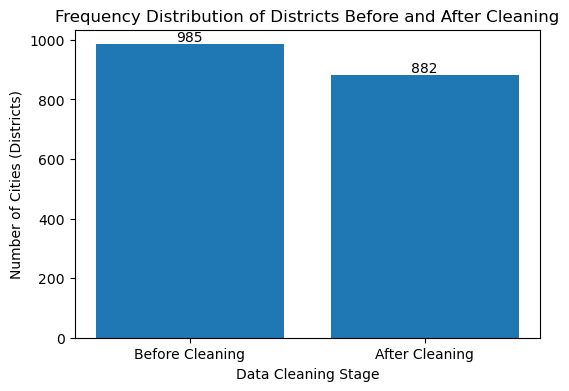

In [30]:
labels = ["Before Cleaning", "After Cleaning"]
district_counts = [985, 882]

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(labels, district_counts)

# Labels & title
plt.xlabel("Data Cleaning Stage")
plt.ylabel("Number of Cities (Districts)")
plt.title("Frequency Distribution of Districts Before and After Cleaning")

# Show values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

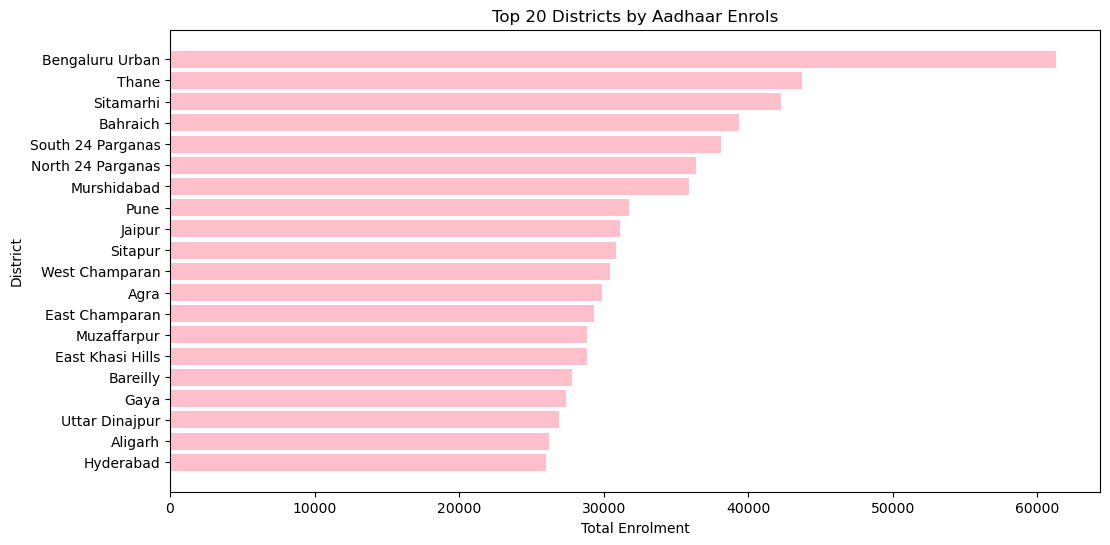

In [31]:
plt.figure(figsize=(12,6))
plt.barh(
    top20_districts["district_clean"],
    top20_districts["total_enrolment"],
    color="Pink"
)
plt.xlabel("Total Enrolment")
plt.ylabel("District")
plt.title("Top 20 Districts by Aadhaar Enrols")
plt.gca().invert_yaxis()
plt.show()

In [32]:
state_summary = (
    df.groupby("state_clean")[["age_0_5", "age_5_17", "age_18_greater"]].sum().reset_index())

In [33]:
state_summary["total_enrolment"] = (
    state_summary["age_0_5"] + state_summary["age_5_17"] + state_summary["age_18_greater"])

In [34]:
df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,state_norm,state_clean,district_norm,district_clean
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37,meghalaya,Meghalaya,east khasi hills,East Khasi Hills
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39,karnataka,Karnataka,bengaluru urban,Bengaluru Urban
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,uttar pradesh,Uttar Pradesh,kanpur nagar,Kanpur Nagar
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15,uttar pradesh,Uttar Pradesh,aligarh,Aligarh
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21,karnataka,Karnataka,bengaluru urban,Bengaluru Urban


In [35]:
age_summary = {
    "Age 0-5": df["age_0_5"].sum(),
    "Age 5-17": df["age_5_17"].sum(),
    "Age 18+": df["age_18_greater"].sum()}
age_summary

{'Age 0-5': np.int64(3546965),
 'Age 5-17': np.int64(1720384),
 'Age 18+': np.int64(168353)}

In [36]:
age_df = pd.DataFrame(
    list(age_summary.items()),
    columns=["Age Group", "Total Enrols"])
age_df

,Age Group,Total Enrols
0,Age 0-5,3546965
1,Age 5-17,1720384
2,Age 18+,168353


In [37]:
age_df["Percentage"] = (
    age_df["Total Enrols"]/ age_df["Total Enrols"].sum()) * 100
age_df

,Age Group,Total Enrols,Percentage
0,Age 0-5,3546965,65.253117
1,Age 5-17,1720384,31.649711
2,Age 18+,168353,3.097171


## Bar Plot of Age

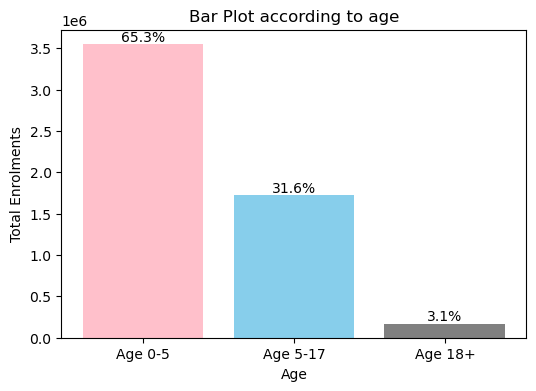

In [38]:
plt.figure(figsize=(6,4))
bars = plt.bar(
    age_df["Age Group"],
    age_df["Total Enrols"],
    color=['Pink', 'Skyblue', 'gray'])
plt.xlabel("Age")
plt.ylabel("Total Enrolments")
plt.title("Bar Plot according to age")

for bar, pct in zip(bars, age_df["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha='center',
        va='bottom')
plt.show()

## now age according to state

In [39]:
state_summary[["state_clean", "age_0_5"]] .sort_values("age_0_5", ascending=False)
state_summary[["state_clean", "age_5_17"]] .sort_values("age_5_17", ascending=False)
state_summary[["state_clean", "age_18_greater"]] .sort_values("age_18_greater", ascending=False)
state_summary["pct_0_5"] = (state_summary["age_0_5"] / state_summary["total_enrolment"]) * 100
state_summary["pct_5_17"] = (state_summary["age_5_17"] / state_summary["total_enrolment"]) * 100
state_summary["pct_18+"] = (state_summary["age_18_greater"] / state_summary["total_enrolment"]) * 100

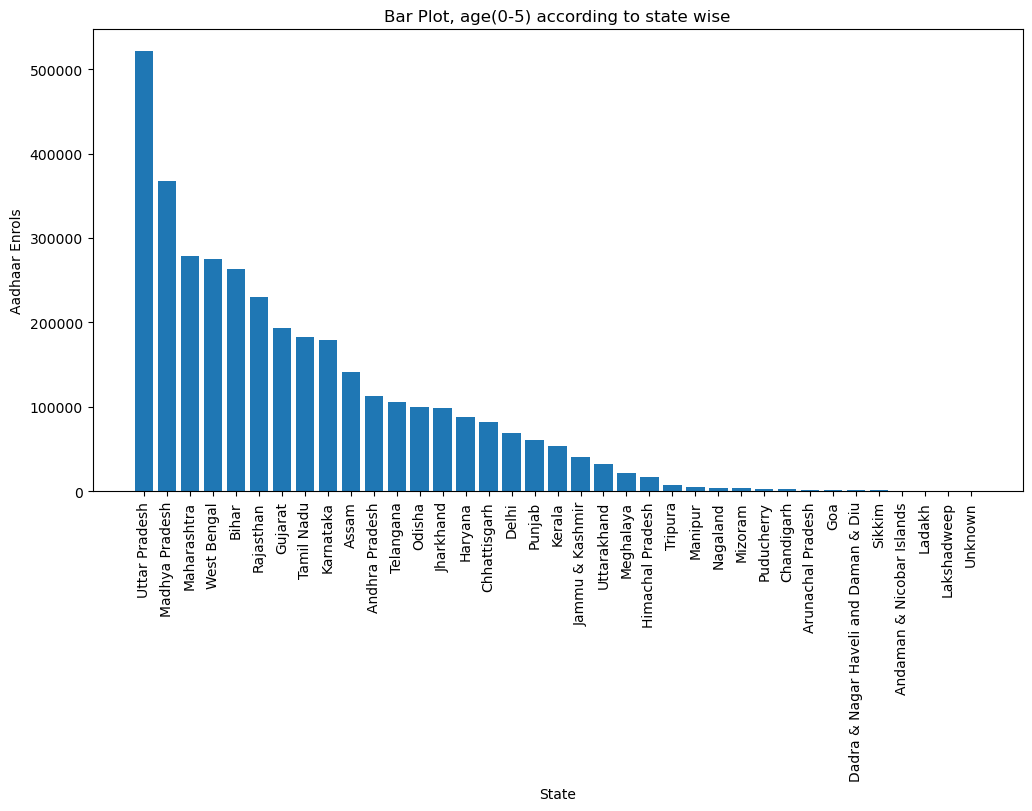

In [40]:
df_0_5 = state_summary.sort_values("age_0_5", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(df_0_5["state_clean"], df_0_5["age_0_5"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Aadhaar Enrols")
plt.title("Bar Plot, age(0-5) according to state wise")
plt.show()

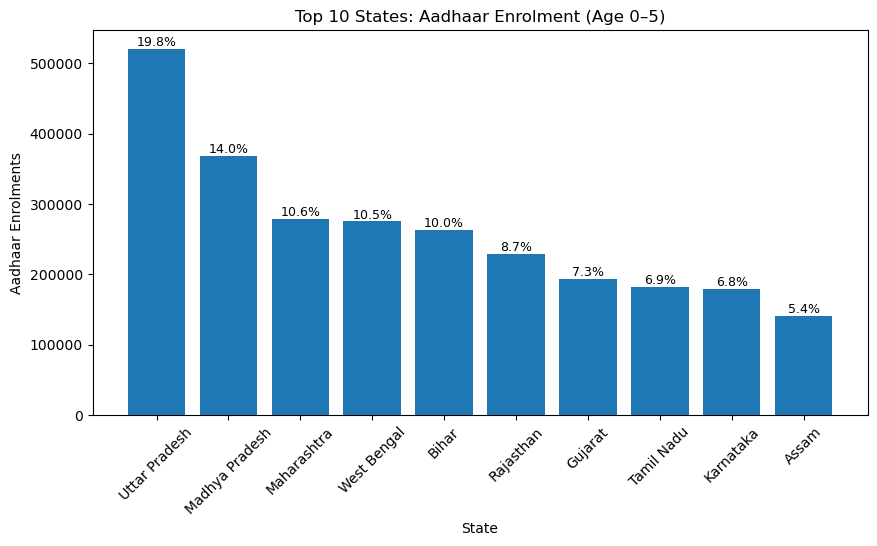

In [41]:
df_0_5_top10 = state_summary.sort_values("age_0_5", ascending=False).head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(
    df_0_5_top10["state_clean"],
    df_0_5_top10["age_0_5"]
)

plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Aadhaar Enrolments")
plt.title("Top 10 States: Aadhaar Enrolment (Age 0–5)")

total_top10_0_5 = df_0_5_top10["age_0_5"].sum()

for bar, value in zip(bars, df_0_5_top10["age_0_5"]):
    percent = (value / total_top10_0_5) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{percent:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9)
plt.show()

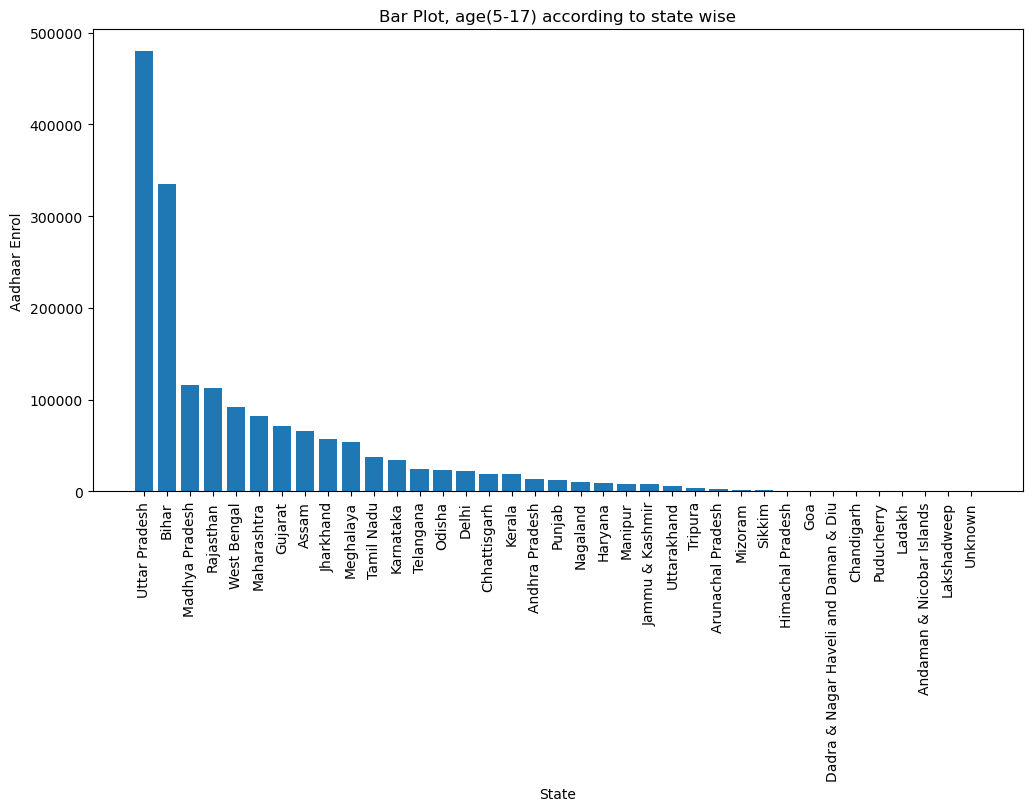

In [42]:
df_5_17 = state_summary.sort_values("age_5_17", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(df_5_17["state_clean"], df_5_17["age_5_17"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Aadhaar Enrol")
plt.title("Bar Plot, age(5-17) according to state wise")
plt.show()

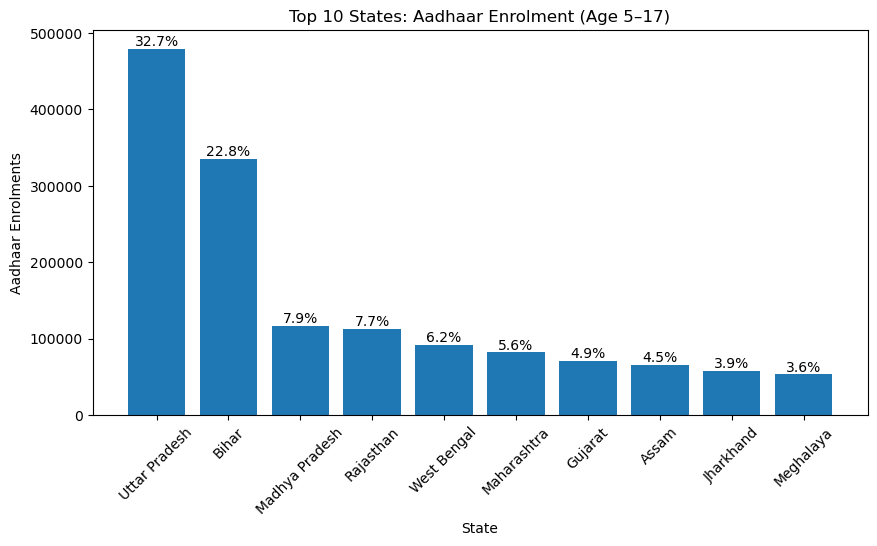

In [43]:
df_5_17 = state_summary.sort_values("age_5_17", ascending=False).head(10)

total_5_17 = df_5_17["age_5_17"].sum()

plt.figure(figsize=(10,5))
bars = plt.bar(df_5_17["state_clean"], df_5_17["age_5_17"])

plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Aadhaar Enrolments")
plt.title("Top 10 States: Aadhaar Enrolment (Age 5–17)")

for bar, value in zip(bars, df_5_17["age_5_17"]):
    percent = (value / total_5_17) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percent:.1f}%",
        ha="center",
        va="bottom")
plt.show()

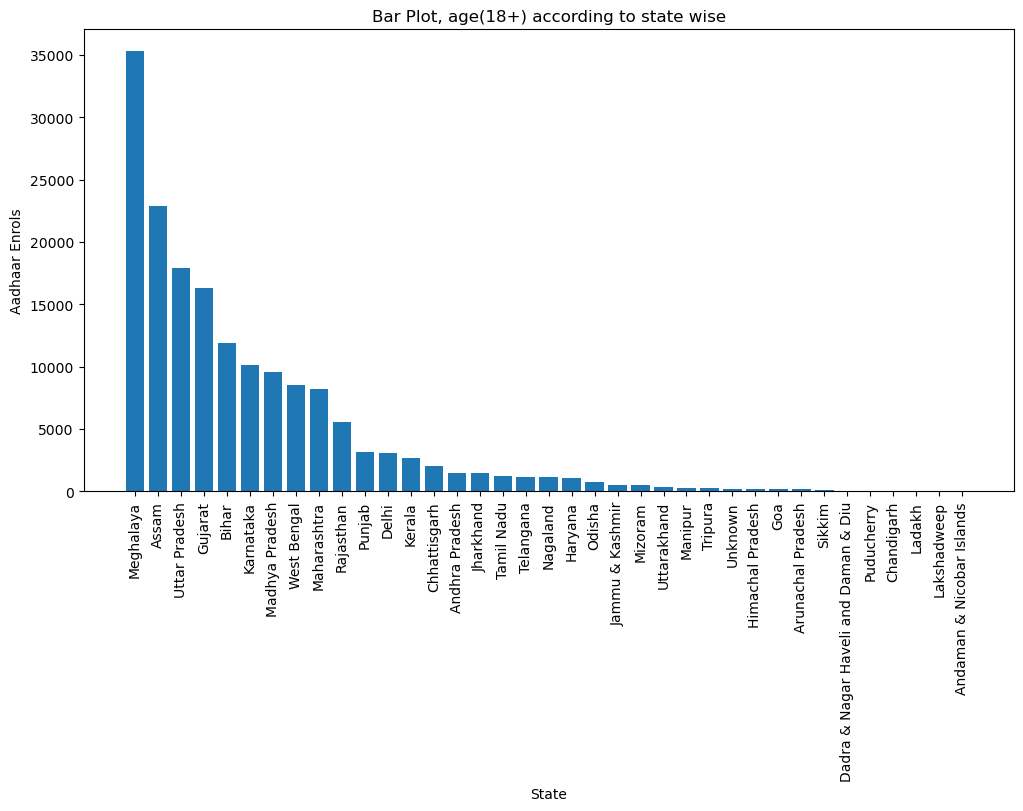

In [44]:
df_18 = state_summary.sort_values("age_18_greater", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(df_18["state_clean"], df_18["age_18_greater"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Aadhaar Enrols")
plt.title("Bar Plot, age(18+) according to state wise")
plt.show()

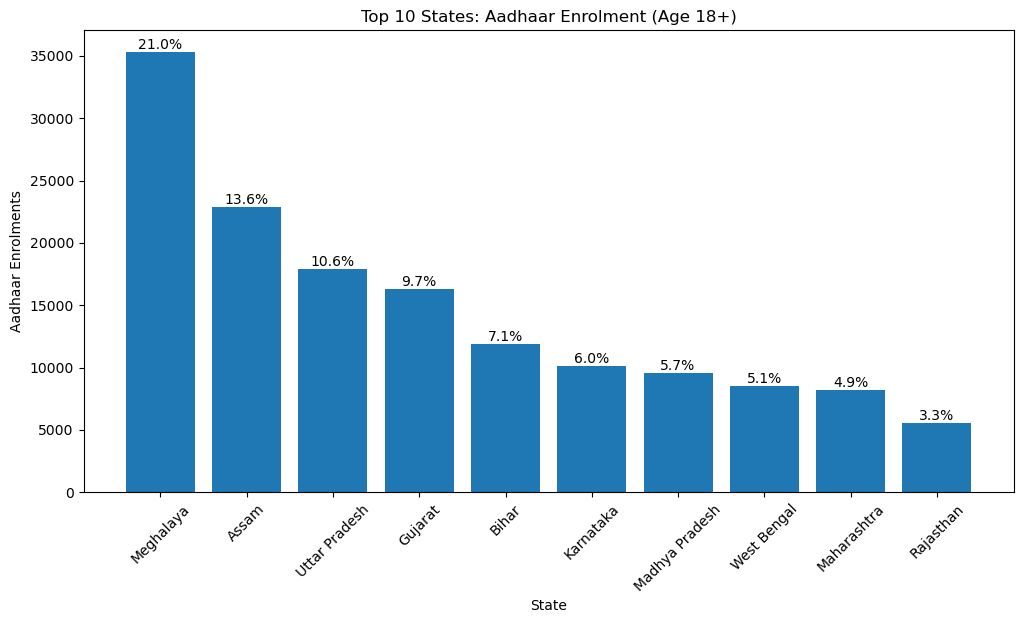

In [45]:
df_18_top10 = state_summary.sort_values(
    "age_18_greater", ascending=False
).head(10)

total_18 = state_summary["age_18_greater"].sum()

plt.figure(figsize=(12,6))

bars = plt.bar(
    df_18_top10["state_clean"],
    df_18_top10["age_18_greater"])
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Aadhaar Enrolments")
plt.title("Top 10 States: Aadhaar Enrolment (Age 18+)")

for bar, value in zip(bars, df_18_top10["age_18_greater"]):
    pct = (value / total_18) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom")
plt.show()

In [46]:
import numpy as np

In [47]:
top10_states = state_summary.sort_values(
    "total_enrolment", ascending=False).head(10)
states = top10_states["state_clean"]
x = np.arange(len(states))
width = 0.25

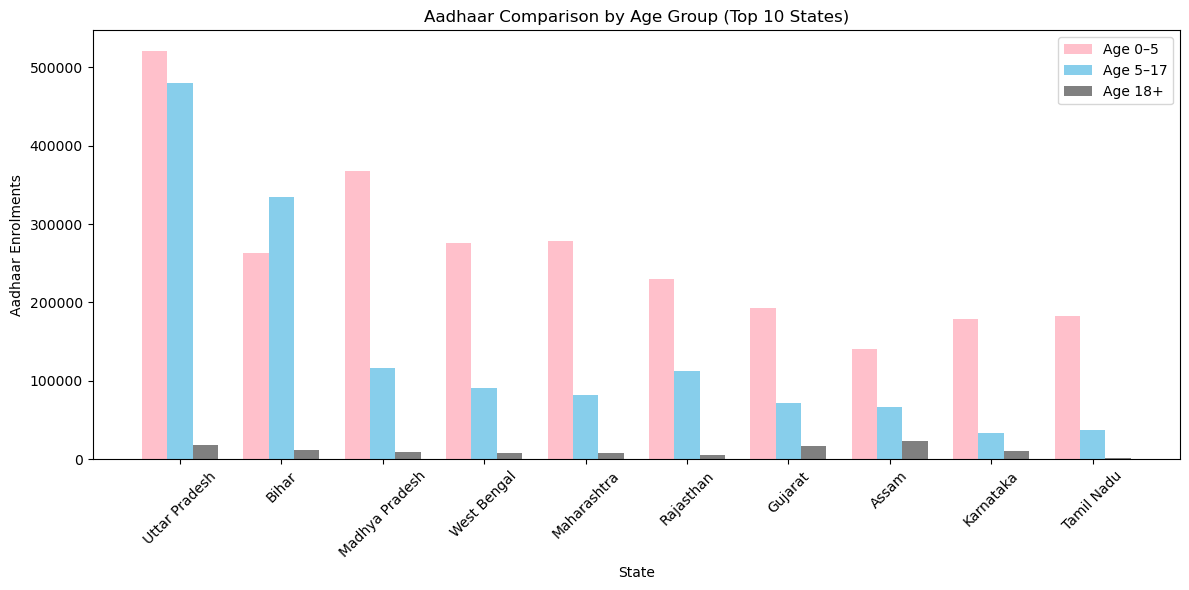

In [48]:
plt.figure(figsize=(12,6))

plt.bar(x - width, top10_states["age_0_5"],
        width, label="Age 0–5", color="pink")

plt.bar(x, top10_states["age_5_17"],
        width, label="Age 5–17", color="skyblue")

plt.bar(x + width, top10_states["age_18_greater"],
        width, label="Age 18+", color="gray")

plt.xticks(x, states, rotation=45)
plt.xlabel("State")
plt.ylabel("Aadhaar Enrolments")
plt.title("Aadhaar Comparison by Age Group (Top 10 States)")
plt.legend()

plt.tight_layout()
plt.show()


In [49]:
age_stats = df[["age_0_5", "age_5_17", "age_18_greater"]].describe()
age_stats

,age_0_5,age_5_17,age_18_greater
count,1.006029e+06,1.006029e+06,1.006029e+06
mean,3.525709e+00,1.710074e+00,1.673441e-01
std,1.753851e+01,1.436963e+01,3.220525e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,0.000000e+00
75%,3.000000e+00,1.000000e+00,0.000000e+00
max,2.688000e+03,1.812000e+03,8.550000e+02


In [50]:
skewness = df[["age_0_5", "age_5_17", "age_18_greater"]].skew()
skewness

age_0_5           43.920908
age_5_17          41.900009
age_18_greater    87.854694
dtype: float64

In [51]:
kurtosis = df[["age_0_5", "age_5_17", "age_18_greater"]].kurtosis()
kurtosis

age_0_5            3105.542611
age_5_17           2477.050126
age_18_greater    12918.557085
dtype: float64

In [52]:
df["log_age_0_5"] = np.log1p(df["age_0_5"])
df["log_age_5_17"] = np.log1p(df["age_5_17"])
df["log_age_18+"] = np.log1p(df["age_18_greater"])

In [53]:
log_stats = df[["log_age_0_5", "log_age_5_17", "log_age_18+"]].describe()
log_stats

,log_age_0_5,log_age_5_17,log_age_18+
count,1.006029e+06,1.006029e+06,1.006029e+06
mean,1.082490e+00,5.035952e-01,4.353398e-02
std,7.207981e-01,6.988282e-01,2.610341e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.931472e-01,0.000000e+00,0.000000e+00
50%,1.098612e+00,0.000000e+00,0.000000e+00
75%,1.386294e+00,6.931472e-01,0.000000e+00
max,7.896925e+00,7.502738e+00,6.752270e+00


In [54]:
log_skew = df[["log_age_0_5", "log_age_5_17", "log_age_18+"]].skew()
log_skew

log_age_0_5     1.178137
log_age_5_17    1.843210
log_age_18+     8.858473
dtype: float64

In [55]:
log_kurt = df[["log_age_0_5", "log_age_5_17", "log_age_18+"]].kurtosis()
log_kurt

log_age_0_5       3.597190
log_age_5_17      5.717233
log_age_18+     101.454302
dtype: float64

C:\Users\aksha\AppData\Local\Temp\ipykernel_36404\3191130688.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


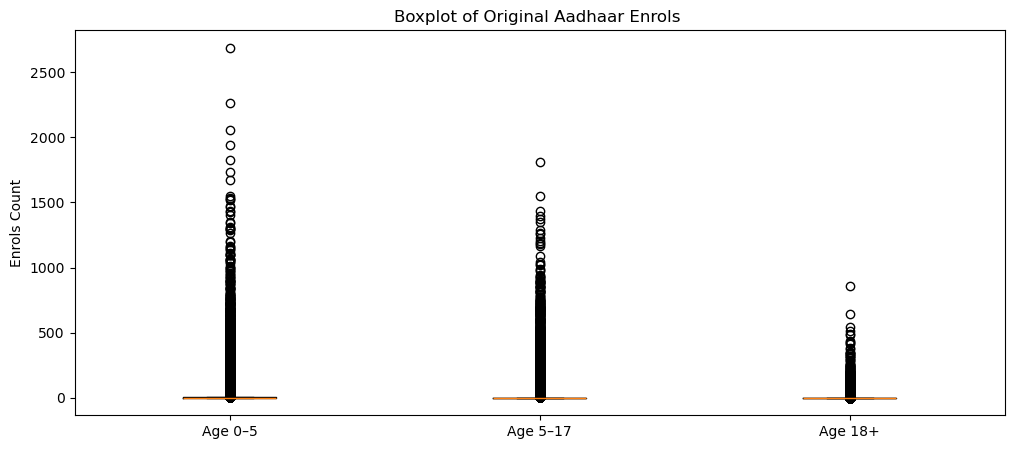

In [56]:
plt.figure(figsize=(12,5))
plt.boxplot(
    [df["age_0_5"], df["age_5_17"], df["age_18_greater"]],
    labels=["Age 0–5", "Age 5–17", "Age 18+"],
    showfliers=True)
plt.title("Boxplot of Original Aadhaar Enrols ")
plt.ylabel("Enrols Count")
plt.show()

C:\Users\aksha\AppData\Local\Temp\ipykernel_36404\3440353872.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


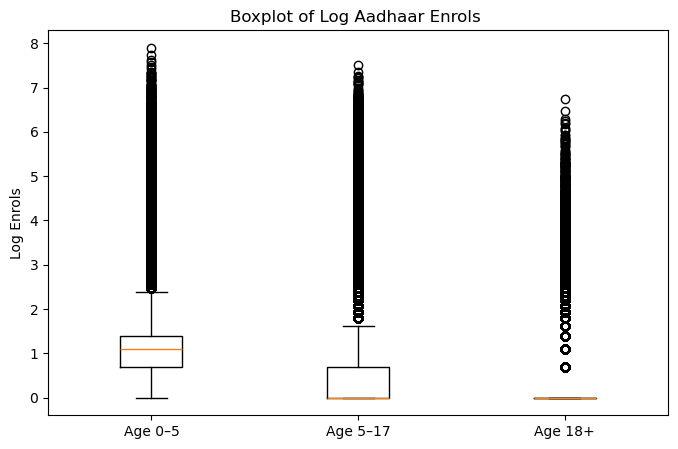

In [57]:
plt.figure(figsize=(8,5))
plt.boxplot(
    [df["log_age_0_5"], df["log_age_5_17"], df["log_age_18+"]],
    labels=["Age 0–5", "Age 5–17", "Age 18+"],
    showfliers=True
)
plt.title("Boxplot of Log Aadhaar Enrols ")
plt.ylabel("Log Enrols")
plt.show()

In [58]:
state_summary["cv_0_5"] = (
    state_summary["age_0_5"].std() / state_summary["age_0_5"].mean())

state_summary["cv_5_17"] = (
    state_summary["age_5_17"].std() / state_summary["age_5_17"].mean())

state_summary["cv_18+"] = (
    state_summary["age_18_greater"].std() / state_summary["age_18_greater"].mean())

state_summary[["cv_0_5", "cv_5_17", "cv_18+"]].head()

,cv_0_5,cv_5_17,cv_18+
0,1.275121,2.042753,1.693825
1,1.275121,2.042753,1.693825
2,1.275121,2.042753,1.693825
3,1.275121,2.042753,1.693825
4,1.275121,2.042753,1.693825


In [59]:
corr_matrix = state_summary[
    ["age_0_5", "age_5_17", "age_18_greater"]].corr()
corr_matrix

,age_0_5,age_5_17,age_18_greater
age_0_5,1.000000,0.826226,0.480488
age_5_17,0.826226,1.000000,0.503293
age_18_greater,0.480488,0.503293,1.000000


In [60]:
from scipy.stats import zscore

In [61]:
state_summary["z_18+"] = zscore(state_summary["age_18_greater"])
extreme_states = state_summary[
    state_summary["z_18+"].abs() > 2]
extreme_states[["state_clean", "age_18_greater", "z_18+"]]

,state_clean,age_18_greater,z_18+
3,Assam,22877,2.410745
22,Meghalaya,35287,4.043171


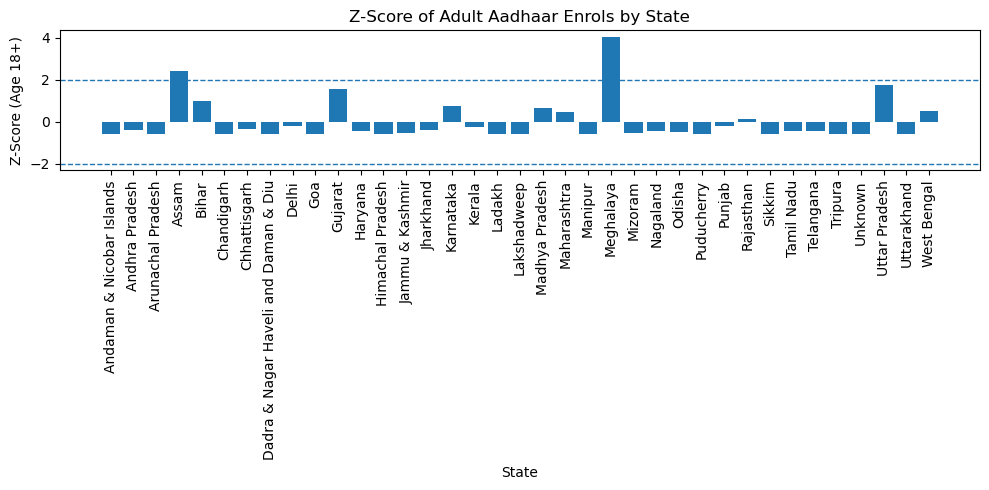

In [62]:
plt.figure(figsize=(10,5))
plt.bar(
    state_summary["state_clean"],
    state_summary["z_18+"])

plt.axhline(2, linestyle="--", linewidth=1)
plt.axhline(-2, linestyle="--", linewidth=1)

plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Z-Score (Age 18+)")
plt.title("Z-Score of Adult Aadhaar Enrols by State")

plt.tight_layout()
plt.show()

In [63]:
district_summary = (
    df.groupby(["state_clean", "district_clean"])
    [["age_0_5", "age_5_17", "age_18_greater"]].sum().reset_index())

district_summary["total_enrolment"] = (
    district_summary["age_0_5"]+ district_summary["age_5_17"]+ district_summary["age_18_greater"])

In [64]:
district_summary["z_total"] = zscore(
    district_summary["total_enrolment"])

In [65]:
extreme_districts = district_summary[
    district_summary["z_total"].abs() > 3]

extreme_districts[
    ["state_clean", "district_clean", "total_enrolment", "z_total"]
].sort_values("z_total", ascending=False)

,state_clean,district_clean,total_enrolment,z_total
356,Karnataka,Bengaluru Urban,61273,7.855914
515,Maharashtra,Thane,43688,5.356584
154,Bihar,Sitamarhi,42232,5.149645
789,Uttar Pradesh,Bahraich,39338,4.738326
903,West Bengal,South 24 Parganas,38141,4.568198
896,West Bengal,North 24 Parganas,36380,4.317910
894,West Bengal,Murshidabad,35911,4.251251
506,Maharashtra,Pune,31763,3.661703
662,Rajasthan,Jaipur,31146,3.574009
856,Uttar Pradesh,Sitapur,30854,3.532508


In [66]:
extreme_districts = district_summary[
    district_summary["z_total"].abs() > 3]

extreme_districts[
    ["state_clean", "district_clean", "total_enrolment", "z_total"]
].sort_values("z_total", ascending=False)


,state_clean,district_clean,total_enrolment,z_total
356,Karnataka,Bengaluru Urban,61273,7.855914
515,Maharashtra,Thane,43688,5.356584
154,Bihar,Sitamarhi,42232,5.149645
789,Uttar Pradesh,Bahraich,39338,4.738326
903,West Bengal,South 24 Parganas,38141,4.568198
896,West Bengal,North 24 Parganas,36380,4.317910
894,West Bengal,Murshidabad,35911,4.251251
506,Maharashtra,Pune,31763,3.661703
662,Rajasthan,Jaipur,31146,3.574009
856,Uttar Pradesh,Sitapur,30854,3.532508


In [67]:
state_summary["child_adult_ratio"] = (
    (state_summary["age_0_5"] + state_summary["age_5_17"]) / state_summary["age_18_greater"])

state_summary.sort_values("child_adult_ratio", ascending=False).head()

,state_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,pct_0_5,pct_5_17,pct_18+,cv_0_5,cv_5_17,cv_18+,z_18+,child_adult_ratio
0,Andaman & Nicobar Islands,479,32,0,511,93.737769,6.262231,0.000000,1.275121,2.042753,1.693825,-0.598523,inf
18,Lakshadweep,192,10,1,203,94.581281,4.926108,0.492611,1.275121,2.042753,1.693825,-0.598392,202.000000
30,Tamil Nadu,182313,37227,1249,220789,82.573407,16.860894,0.565698,1.275121,2.042753,1.693825,-0.434228,175.772618
25,Odisha,99431,22817,739,122987,80.846756,18.552367,0.600877,1.275121,2.042753,1.693825,-0.501314,165.423545
31,Telangana,105918,24505,1151,131574,80.500707,18.624500,0.874793,1.275121,2.042753,1.693825,-0.447119,113.312772


In [68]:
demo1 = pd.read_csv("api_data_aadhar_demographic_0_500000.csv")
demo2 = pd.read_csv("api_data_aadhar_demographic_500000_1000000.csv")
demo3 = pd.read_csv("api_data_aadhar_demographic_1000000_1500000.csv")
demo4 = pd.read_csv("api_data_aadhar_demographic_1500000_2000000.csv")
demo5 = pd.read_csv("api_data_aadhar_demographic_2000000_2071700.csv")

demo_df = pd.concat([demo1, demo2, demo3, demo4, demo5], ignore_index=True)
demo_df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785


In [69]:
demo_df.shape

(2071700, 6)

In [70]:
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071700 entries, 0 to 2071699
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   date           object
 1   state          object
 2   district       object
 3   pincode        int64 
 4   demo_age_5_17  int64 
 5   demo_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 94.8+ MB


In [71]:
demo_df["state"].value_counts()

state
Andhra Pradesh          207687
Tamil Nadu              196857
West Bengal             168623
Uttar Pradesh           167889
Maharashtra             162242
                         ...  
Jaipur                       2
Madanapalle                  2
Puttenahalli                 1
Nagpur                       1
Raja Annamalai Puram         1
Name: count, Length: 65, dtype: int64

In [72]:
demo_df["state"].unique()

array(['Uttar Pradesh', 'Andhra Pradesh', 'Gujarat', 'Rajasthan',
       'Karnataka', 'West Bengal', 'Telangana', 'Odisha', 'Maharashtra',
       'Kerala', 'Bihar', 'Tamil Nadu', 'Madhya Pradesh', 'Assam',
       'Tripura', 'Arunachal Pradesh', 'Punjab', 'Jharkhand', 'Delhi',
       'Chandigarh', 'Chhattisgarh', 'Jammu and Kashmir', 'Mizoram',
       'Nagaland', 'Himachal Pradesh', 'Goa', 'Haryana', 'Meghalaya',
       'Uttarakhand', 'Manipur', 'Daman and Diu', 'Puducherry', 'Sikkim',
       'Ladakh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Dadra and Nagar Haveli', 'Orissa', 'Pondicherry',
       'Andaman & Nicobar Islands', 'Andaman and Nicobar Islands',
       'west Bengal', 'Daman & Diu', 'West  Bengal', 'odisha',
       'Jammu & Kashmir', 'Lakshadweep', 'Dadra & Nagar Haveli',
       'Westbengal', 'andhra pradesh', 'WEST BENGAL', 'West Bangal',
       'West bengal', 'ODISHA', 'WESTBENGAL', 'Chhatisgarh',
       'West Bengli', 'Darbhanga', 'Puttenahalli', 'BALANAGAR',
  

In [73]:
demo_df["state"].nunique()

65

In [74]:
sorted_states = sorted(demo_df["state"].astype(str).unique())
sorted_states

['100000',
 'Andaman & Nicobar Islands',
 'Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'BALANAGAR',
 'Bihar',
 'Chandigarh',
 'Chhatisgarh',
 'Chhattisgarh',
 'Dadra & Nagar Haveli',
 'Dadra and Nagar Haveli',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Daman & Diu',
 'Daman and Diu',
 'Darbhanga',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jaipur',
 'Jammu & Kashmir',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madanapalle',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Nagpur',
 'ODISHA',
 'Odisha',
 'Orissa',
 'Pondicherry',
 'Puducherry',
 'Punjab',
 'Puttenahalli',
 'Raja Annamalai Puram',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'Uttaranchal',
 'WEST BENGAL',
 'WESTBENGAL',
 'West  Bengal',
 'West Bangal',
 'West Bengal',
 'West Bengli',
 'West bengal',
 'Westbengal',
 'an

In [75]:
demo_df["state_norm"] = (
    demo_df["state"].astype(str).str.strip().str.lower().str.replace(r"\s+", " ", regex=True))

In [76]:
state_clean_map = {
    "andhra pradesh": "Andhra Pradesh",

    "arunachal pradesh": "Arunachal Pradesh",

    "assam": "Assam",

    "bihar": "Bihar",

    "chhattisgarh": "Chhattisgarh",
    "chhatisgarh": "Chhattisgarh",

    "goa": "Goa",

    "gujarat": "Gujarat",

    "haryana": "Haryana",

    "himachal pradesh": "Himachal Pradesh",

    "jharkhand": "Jharkhand",

    "karnataka": "Karnataka",

    "kerala": "Kerala",

    "madhya pradesh": "Madhya Pradesh",

    "maharashtra": "Maharashtra",

    "manipur": "Manipur",

    "meghalaya": "Meghalaya",

    "mizoram": "Mizoram",

    "nagaland": "Nagaland",

    "odisha": "Odisha",
    "orissa": "Odisha",

    "punjab": "Punjab",

    "rajasthan": "Rajasthan",

    "sikkim": "Sikkim",

    "tamil nadu": "Tamil Nadu",

    "telangana": "Telangana",

    "tripura": "Tripura",

    "uttar pradesh": "Uttar Pradesh",

    "uttarakhand": "Uttarakhand",
    "uttaranchal": "Uttarakhand",

    "west bengal": "West Bengal",
    "westbengal": "West Bengal",
    "west  bengal": "West Bengal",
    "west bangal": "West Bengal",
    "west bengli": "West Bengal",

    "delhi": "Delhi",
    "chandigarh": "Chandigarh",
    "ladakh": "Ladakh",
    "lakshadweep": "Lakshadweep",

    "jammu and kashmir": "Jammu & Kashmir",
    "jammu & kashmir": "Jammu & Kashmir",

    "puducherry": "Puducherry",
    "pondicherry": "Puducherry",

    "andaman & nicobar islands": "Andaman & Nicobar Islands",
    "andaman and nicobar islands": "Andaman & Nicobar Islands",

    "daman and diu": "Dadra & Nagar Haveli and Daman & Diu",
    "daman & diu": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra and nagar haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra & nagar haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra and nagar haveli and daman and diu": "Dadra & Nagar Haveli and Daman & Diu",

    "darbhanga": "Unknown",
    "puttenahalli": "Unknown",
    "balanagar": "Unknown",
    "jaipur": "Unknown",
    "madanapalle": "Unknown",
    "nagpur": "Unknown",
    "raja annamalai puram": "Unknown",
    "100000": "Unknown"
}

In [77]:
demo_df["state_clean"] = demo_df["state_norm"].replace(state_clean_map)
demo_df["state_clean"].nunique()

37

In [78]:
demo_df = demo_df[demo_df["state_clean"] != "Unknown"]

In [79]:
demo_state_summary = (
    demo_df.groupby("state_clean")[["demo_age_5_17", "demo_age_17_"]].sum().reset_index())

In [80]:
demo_state_summary["total_population"] = (
    demo_state_summary["demo_age_5_17"]+ demo_state_summary["demo_age_17_"])

In [81]:
demo_state_summary.head()

,state_clean,demo_age_5_17,demo_age_17_,total_population
0,Andaman & Nicobar Islands,617,6629,7246
1,Andhra Pradesh,321148,1974434,2295582
2,Arunachal Pradesh,5783,30660,36443
3,Assam,84480,928098,1012578
4,Bihar,380023,4434327,4814350


In [82]:
demo_df["district"].nunique()

975

In [83]:
demo_df["district"].unique()

array(['Gorakhpur', 'Chittoor', 'Rajkot', 'Srikakulam', 'Udaipur',
       'Sikar', 'Tumakuru', 'Kurnool', 'Paschim Medinipur', 'Ghazipur',
       'Patan', 'Mulugu', 'Ganganagar', 'Nayagarh', 'Nashik',
       'Shivamogga', 'Thrissur', 'Hassan', 'Patna', 'Belgaum',
       'Kancheepuram', 'Jabalpur', 'Chennai', 'Tinsukia', 'Jamui', 'Gaya',
       'Bengaluru', 'Tiruppur', 'Jalgaon', 'Dhalai', 'Nabarangapur',
       'Chittorgarh', 'Darbhanga', 'Purnia', 'Muzaffarnagar', 'Jaipur',
       'Churu', 'Bharatpur', 'Jamnagar', 'Howrah', 'Ahmedabad',
       'West Kameng', 'Jalor', 'Belagavi', 'Bahraich', 'Nagapattinam',
       'Sheikhpura', 'Amritsar', 'Mysore', 'Alluri Sitharama Raju',
       'Sitamarhi', 'Khunti', 'Saharanpur', 'Kanyakumari', 'Prakasam',
       'Ananthapuramu', 'Hooghly', 'Central Delhi', 'Deoria', 'Giridih',
       'Koraput', 'Shahjahanpur', 'Chhotaudepur', 'Jalandhar', 'Kannauj',
       'Visakhapatnam', 'Jodhpur', 'Karimnagar', 'Amethi', 'Hyderabad',
       'Salem', 'Cuddalore'

In [84]:
demo_df["district_norm"] = (
    demo_df["district"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace(r"[^\w\s]", "", regex=True)
)

In [85]:
district_clean_map = {

    "angul": "Angul",
    "anugul": "Angul",
    "anugal": "Angul",
    "aurangabad(bh)": "Aurangabad",
    "bagalkot *": "Bagalkot",
    "baghpat *": "Baghpat",
    "chamarajanagar *": "Chamarajanagar",
    "chamrajnagar": "Chamarajanagar",
    "chandauli *": "Chandauli",
    "chitrakoot *": "Chitrakoot",
    "chittoor": "Chittoor",
    "deeg\xa0": "Deeg",
    "dhalai *": "Dhalai",
    "dhalai  *": "Dhalai",
    "dist : thane": "Thane",
    "gadag *": "Gadag",
    "garhwa *": "Garhwa",
    "gondiya": "Gondia",
    "gondiya *": "Gondia",
    "harda *": "Harda",
    "haveri *": "Haveri",
    "hingoli *": "Hingoli",
    "hooghly": "Hooghly",
    "hugli": "Hooghly",
    "howrah": "Howrah",
    "hawrah": "Howrah",
    "jajapur": "Jajpur",
    "jajapur  *": "Jajpur",
    "jajpur": "Jajpur",
    "jyotiba phule nagar": "Amroha",
    "jyotiba phule nagar *": "Amroha",
    "kolkata": "Kolkata",
    "kushinagar *": "Kushinagar",
    "malda": "Malda",
    "nadia": "Nadia",
    "nandurbar *": "Nandurbar",
    "nuapada": "Nuapada",
    "rangareddi": "Rangareddy",
    "seraikela-kharsawan": "Seraikela-Kharsawan",
    "south 24 pargana": "South 24 Parganas",
    "south 24 parganas": "South 24 Parganas",
    "south  twenty four parganas": "South 24 Parganas",
    "south twenty four parganas": "South 24 Parganas",
    "udham singh nagar *": "Udham Singh Nagar",
    "udupi *": "Udupi",
    "washim *": "Washim",
    "yadgir": "Yadgir",
    "100000": "Unknown",

    "allahabad": "Prayagraj",
    "bangalore": "Bengaluru Urban",
    "bengaluru": "Bengaluru Urban",
    "bengaluru south": "Bengaluru Urban",
    "bangalore rural": "Bengaluru Rural",
    "belgaum": "Belagavi",
    "bijapur": "Vijayapura",
    "bijapur(kar)": "Vijayapura",
    "chickmagalur": "Chikkamagaluru",
    "coochbehar": "Cooch Behar",
    "dadra & nagar haveli": "Dadra & Nagar Haveli",
    "dadra and nagar haveli": "Dadra & Nagar Haveli",
    "east midnapore": "Purba Medinipur",
    "east midnapur": "Purba Medinipur",
    "faizabad": "Ayodhya",
    "gurgaon": "Gurugram",
    "gulbarga": "Kalaburagi",
    "kheri": "Lakhimpur Kheri",
    "lakhimpur": "Lakhimpur Kheri", 
    "leh (ladakh)": "Leh",
    "mahbubnagar": "Mahbubnagar",
    "mahabub nagar": "Mahbubnagar",
    "medinipur": "Paschim Medinipur",
    "medinipur west": "Paschim Medinipur",
    "west medinipur": "Paschim Medinipur",
    "mohali": "S.A.S. Nagar",
    "s.a.s nagar(mohali)": "S.A.S. Nagar",
    "sas nagar (mohali)": "S.A.S. Nagar",
    "mysore": "Mysuru",
    "narsimhapur": "Narsinghpur",
    "north east": "North East Delhi",
    "osmanabad": "Dharashiv",
    "pondicherry": "Puducherry",
    "shimoga": "Shivamogga",
    "tuticorin": "Thoothukkudi",

    "bally jagachha": "Howrah",
    "balianta": "Khordha",
    "bicholim": "North Goa",
    "domjur": "Howrah",
    "naihati anandabazar": "North 24 Parganas",
    "south dumdum(m)": "North 24 Parganas",
    "bhadrak(r)": "Bhadrak",

    "medchalâ\x88\x92malkajgiri": "Medchal-Malkajgiri",
    "medchal-malkajgiri": "Medchal-Malkajgiri",
    "medchal?malkajgiri": "Medchal-Malkajgiri"
}

demo_df["district_clean"] = demo_df["district_norm"].map(district_clean_map).fillna(demo_df["district_norm"].str.title())

print(sorted(demo_df["district_clean"].unique()))

['Adilabad', 'Agar Malwa', 'Agra', 'Ahilyanagar', 'Ahmadabad', 'Ahmadnagar', 'Ahmed Nagar', 'Ahmedabad', 'Aizawl', 'Ajmer', 'Akola', 'Alappuzha', 'Aligarh', 'Alipurduar', 'Alirajpur', 'Alluri Sitharama Raju', 'Almora', 'Alwar', 'Ambala', 'Ambedkar Nagar', 'Amethi', 'Amravati', 'Amreli', 'Amritsar', 'Amroha', 'Anakapalli', 'Anand', 'Anantapur', 'Ananthapur', 'Ananthapuramu', 'Anantnag', 'Andamans', 'Angul', 'Anjaw', 'Annamayya', 'Anuppur', 'Araria', 'Ariyalur', 'Arvalli', 'Arwal', 'Ashok Nagar', 'Auraiya', 'Aurangabad', 'Aurangabadbh', 'Ayodhya', 'Azamgarh', 'Badgam', 'Bagalkot', 'Bagalkot ', 'Bageshwar', 'Baghpat', 'Baghpat ', 'Bagpat', 'Bahraich', 'Bajali', 'Baksa', 'Balaghat', 'Balangir', 'Baleshwar', 'Baleswar', 'Ballari', 'Ballia', 'Balod', 'Baloda Bazar', 'Balotra', 'Balrampur', 'Banas Kantha', 'Banaskantha', 'Banda', 'Bandipore', 'Bandipur', 'Banka', 'Bankura', 'Banswara', 'Bapatla', 'Bara Banki', 'Barabanki', 'Baramula', 'Baran', 'Barddhaman', 'Bardez', 'Bardhaman', 'Bareilly', 

In [86]:
demo_df["district_clean"] = (
    demo_df["district_norm"].replace(district_clean_map).str.title())

demo_df["district_clean"].nunique()

911

In [87]:
demo_df = demo_df[demo_df["district_clean"] != "Unknown"]

In [88]:
demo_district_summary = (
    demo_df.groupby(["state_clean", "district_clean"])
    [["demo_age_5_17", "demo_age_17_"]].sum().reset_index())

demo_district_summary["total_population"] = (
    demo_district_summary["demo_age_5_17"] +demo_district_summary["demo_age_17_"])

demo_district_summary.head()

,state_clean,district_clean,demo_age_5_17,demo_age_17_,total_population
0,Andaman & Nicobar Islands,Andamans,7,743,750
1,Andaman & Nicobar Islands,Nicobar,58,729,787
2,Andaman & Nicobar Islands,Nicobars,0,4,4
3,Andaman & Nicobar Islands,North And Middle Andaman,112,1897,2009
4,Andaman & Nicobar Islands,South Andaman,440,3256,3696


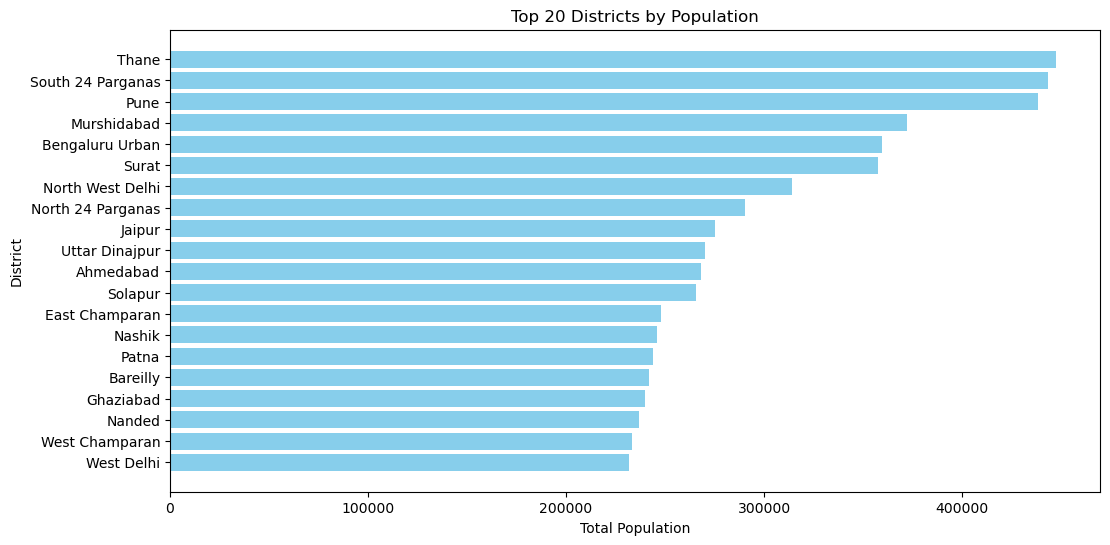

In [89]:
top20_demo_districts = (
    demo_district_summary
    .sort_values("total_population", ascending=False)
    .head(20))

plt.figure(figsize=(12,6))
plt.barh(
    top20_demo_districts["district_clean"],
    top20_demo_districts["total_population"],
    color="skyblue")
plt.xlabel("Total Population")
plt.ylabel("District")
plt.title("Top 20 Districts by Population")
plt.gca().invert_yaxis()
plt.show()

In [90]:
final_district_df = pd.merge(
    district_summary,
    demo_district_summary,
    on=["state_clean", "district_clean"],
    how="inner")

final_district_df.head()

,state_clean,district_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,z_total,demo_age_5_17,demo_age_17_,total_population
0,Andaman & Nicobar Islands,Andamans,70,5,0,75,-0.842064,7,743,750
1,Andaman & Nicobar Islands,Nicobar,64,11,0,75,-0.842064,58,729,787
2,Andaman & Nicobar Islands,Nicobars,1,0,0,1,-0.852582,0,4,4
3,Andaman & Nicobar Islands,North And Middle Andaman,128,4,0,132,-0.833963,112,1897,2009
4,Andaman & Nicobar Islands,South Andaman,216,12,0,228,-0.820319,440,3256,3696


In [91]:
final_district_df["coverage_5_17"] = (
    final_district_df["age_5_17"] /final_district_df["demo_age_5_17"])

final_district_df["coverage_17_plus"] = (
    final_district_df["age_18_greater"] /final_district_df["demo_age_17_"])

final_district_df.replace([np.inf, -np.inf], np.nan, inplace=True)
final_district_df.dropna(subset=["coverage_17_plus"], inplace=True)

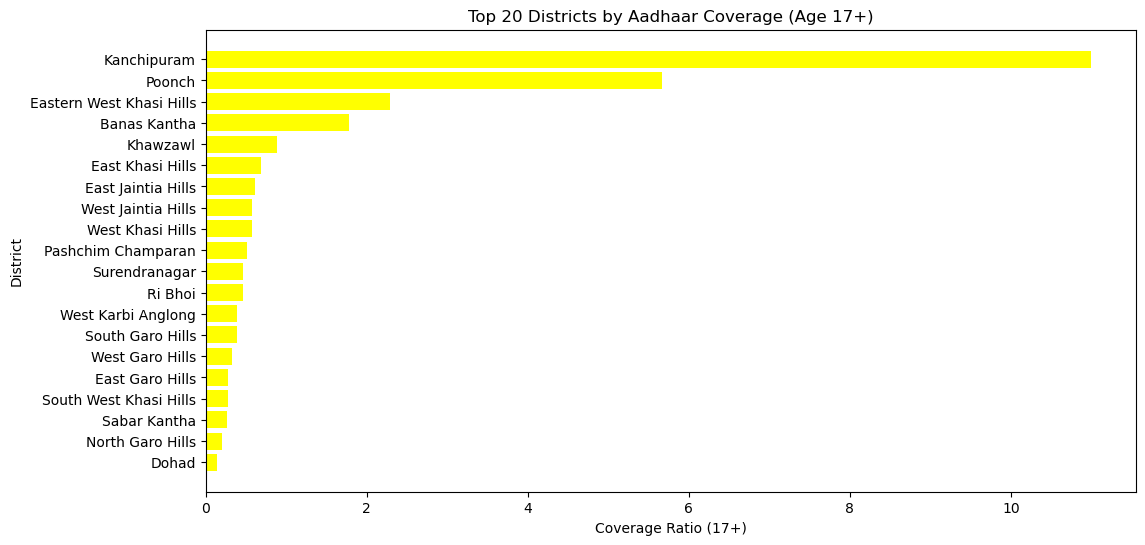

In [92]:
top20_coverage = (
    final_district_df
    .sort_values("coverage_17_plus", ascending=False)
    .head(20))

plt.figure(figsize=(12,6))
plt.barh(
    top20_coverage["district_clean"],
    top20_coverage["coverage_17_plus"],
    color="Yellow")
plt.xlabel("Coverage Ratio (17+)")
plt.ylabel("District")
plt.title("Top 20 Districts by Aadhaar Coverage (Age 17+)")
plt.gca().invert_yaxis()
plt.show()

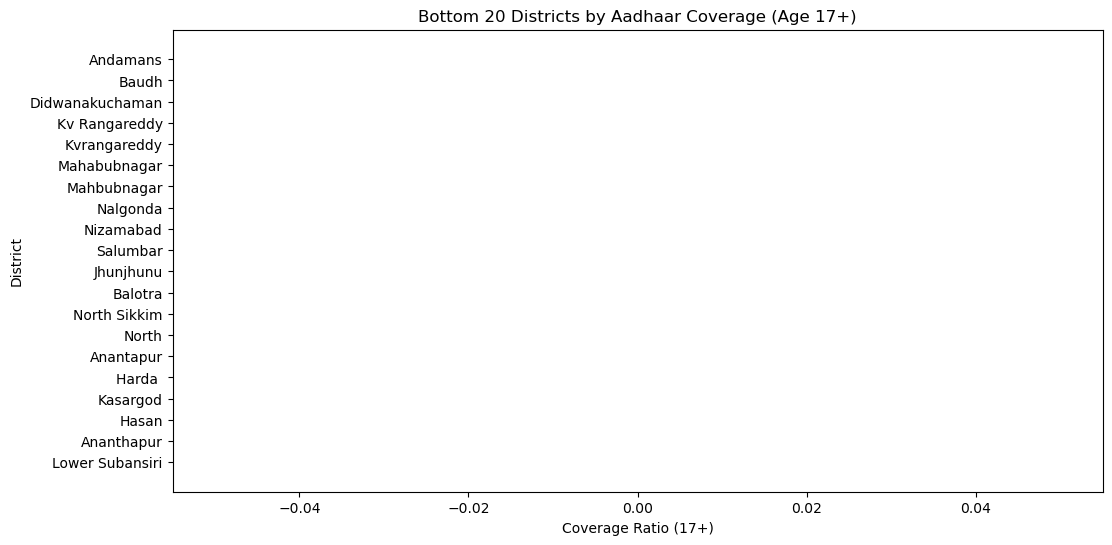

In [93]:
bottom20_coverage = (
    final_district_df
    .sort_values("coverage_17_plus", ascending=True)
    .head(20)
)

plt.figure(figsize=(12,6))
plt.barh(
    bottom20_coverage["district_clean"],
    bottom20_coverage["coverage_17_plus"],
    color="pink"
)
plt.xlabel("Coverage Ratio (17+)")
plt.ylabel("District")
plt.title("Bottom 20 Districts by Aadhaar Coverage (Age 17+)")
plt.gca().invert_yaxis()
plt.show()


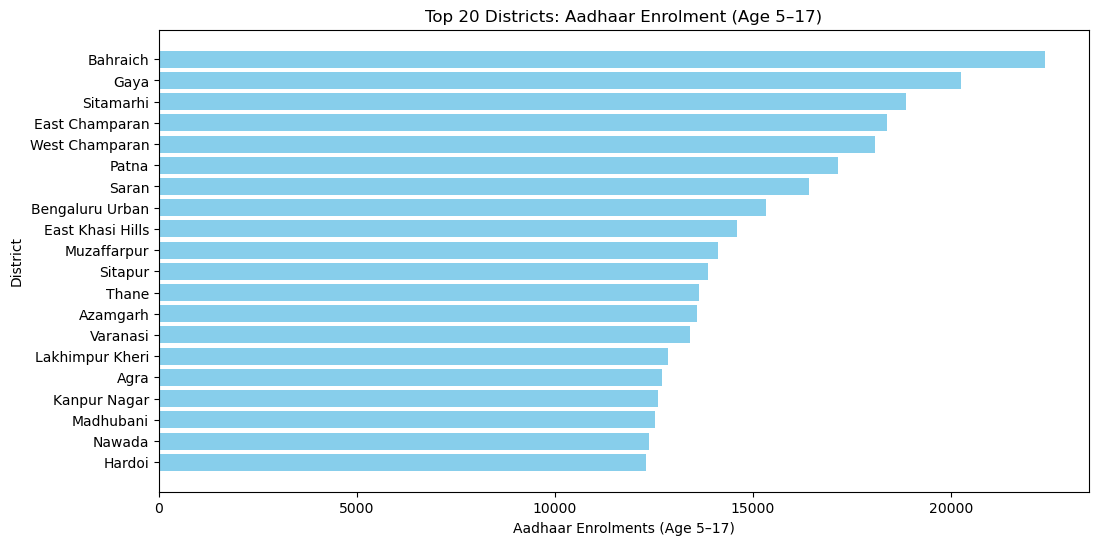

In [94]:
top20_child = (
    district_summary
    .sort_values("age_5_17", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))
plt.barh(
    top20_child["district_clean"],
    top20_child["age_5_17"],
    color="skyblue"
)
plt.xlabel("Aadhaar Enrolments (Age 5–17)")
plt.ylabel("District")
plt.title("Top 20 Districts: Aadhaar Enrolment (Age 5–17)")
plt.gca().invert_yaxis()
plt.show()

In [95]:
# from enrolment dataset
district_summary

,state_clean,district_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,z_total
0,Andaman & Nicobar Islands,Andamans,70,5,0,75,-0.842064
1,Andaman & Nicobar Islands,Nicobar,64,11,0,75,-0.842064
2,Andaman & Nicobar Islands,Nicobars,1,0,0,1,-0.852582
3,Andaman & Nicobar Islands,North And Middle Andaman,128,4,0,132,-0.833963
4,Andaman & Nicobar Islands,South Andaman,216,12,0,228,-0.820319
...,...,...,...,...,...,...,...
901,West Bengal,Purba Medinipur,14751,1628,62,16441,1.484010
902,West Bengal,Purulia,10213,3655,134,14002,1.137359
903,West Bengal,South 24 Parganas,28384,9427,330,38141,4.568198
904,West Bengal,South Dinajpur,375,71,0,446,-0.789335


In [96]:
final_district_df = pd.merge(
    district_summary,
    demo_district_summary,
    on=["state_clean", "district_clean"],
    how="inner")

final_district_df.head()

,state_clean,district_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,z_total,demo_age_5_17,demo_age_17_,total_population
0,Andaman & Nicobar Islands,Andamans,70,5,0,75,-0.842064,7,743,750
1,Andaman & Nicobar Islands,Nicobar,64,11,0,75,-0.842064,58,729,787
2,Andaman & Nicobar Islands,Nicobars,1,0,0,1,-0.852582,0,4,4
3,Andaman & Nicobar Islands,North And Middle Andaman,128,4,0,132,-0.833963,112,1897,2009
4,Andaman & Nicobar Islands,South Andaman,216,12,0,228,-0.820319,440,3256,3696


In [97]:
final_district_df["coverage_5_17"] = (
    final_district_df["age_5_17"] /final_district_df["demo_age_5_17"])

final_district_df["coverage_17_plus"] = (
    final_district_df["age_18_greater"] /final_district_df["demo_age_17_"])

In [98]:
final_district_df[
    final_district_df["coverage_17_plus"] < 0.75
][["state_clean", "district_clean", "coverage_17_plus"]]

,state_clean,district_clean,coverage_17_plus
0,Andaman & Nicobar Islands,Andamans,0.000000
1,Andaman & Nicobar Islands,Nicobar,0.000000
2,Andaman & Nicobar Islands,Nicobars,0.000000
3,Andaman & Nicobar Islands,North And Middle Andaman,0.000000
4,Andaman & Nicobar Islands,South Andaman,0.000000
...,...,...,...
865,West Bengal,Purba Medinipur,0.000525
866,West Bengal,Purulia,0.019353
867,West Bengal,South 24 Parganas,0.000796
868,West Bengal,South Dinajpur,0.000000


In [99]:
demo_age_df = pd.DataFrame({
    "Age Group": ["Age 5–17", "Age 17+"],
    "Total Count": [demo_df["demo_age_5_17"].sum(),demo_df["demo_age_17_"].sum()]})

In [100]:
demo_age_df["Percentage"] = (
    demo_age_df["Total Count"] / demo_age_df["Total Count"].sum()) * 100
demo_age_df

,Age Group,Total Count,Percentage
0,Age 5–17,4863424,9.865923
1,Age 17+,44431750,90.134077


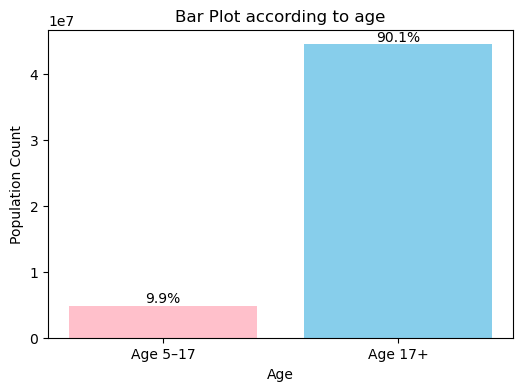

In [101]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    demo_age_df["Age Group"],
    demo_age_df["Total Count"],
    color=['Pink', 'Skyblue', 'gray'])
plt.xlabel("Age")
plt.ylabel("Population Count")
plt.title("Bar Plot according to age")


for bar, pct in zip(bars, demo_age_df["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom")
plt.show()

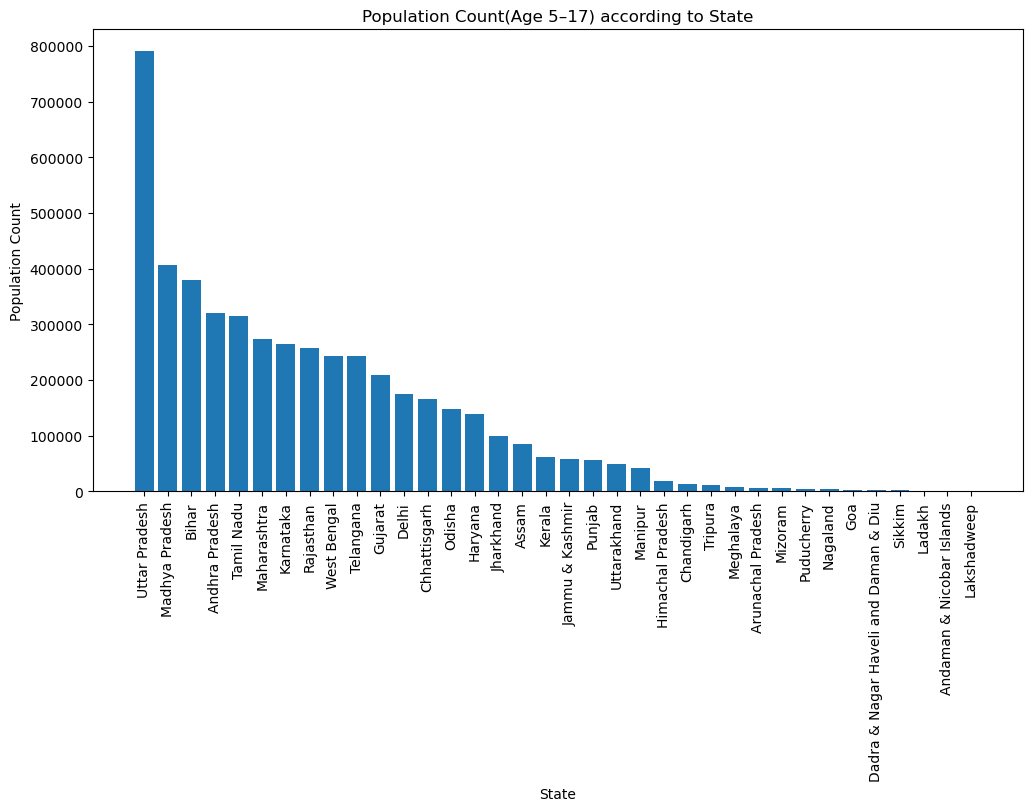

In [102]:
df_5_17_demo = demo_state_summary.sort_values("demo_age_5_17", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_5_17_demo["state_clean"], df_5_17_demo["demo_age_5_17"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Population Count")
plt.title("Population Count(Age 5–17) according to State")
plt.show()

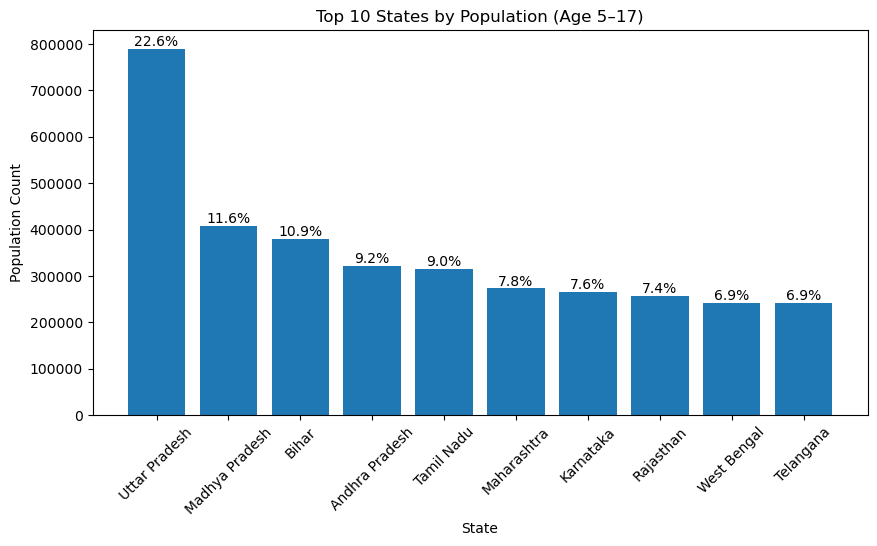

In [103]:
top10_5_17 = df_5_17_demo.head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(
    top10_5_17["state_clean"],
    top10_5_17["demo_age_5_17"])

plt.xlabel("State")
plt.ylabel("Population Count")
plt.title("Top 10 States by Population (Age 5–17)")
plt.xticks(rotation=45)

total_5_17 = top10_5_17["demo_age_5_17"].sum()

for bar, value in zip(bars, top10_5_17["demo_age_5_17"]):
    pct = (value / total_5_17) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom")
plt.show()

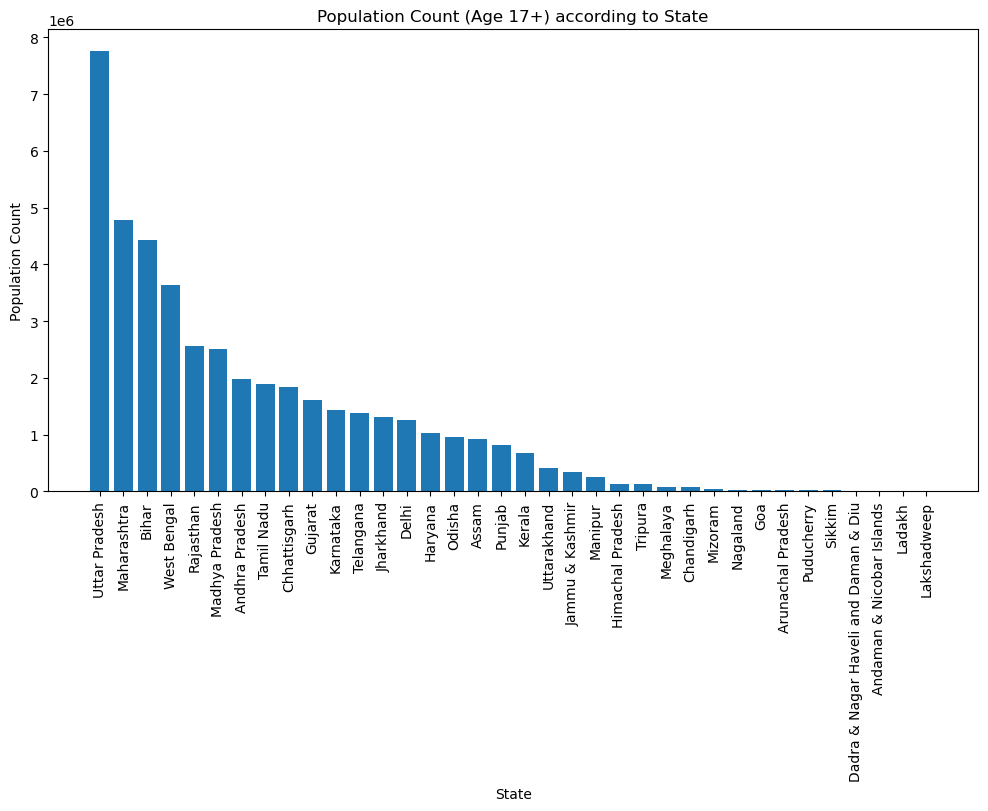

In [104]:
df_17_demo = demo_state_summary.sort_values("demo_age_17_", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(df_17_demo["state_clean"], df_17_demo["demo_age_17_"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Population Count")
plt.title("Population Count (Age 17+) according to State")
plt.show()

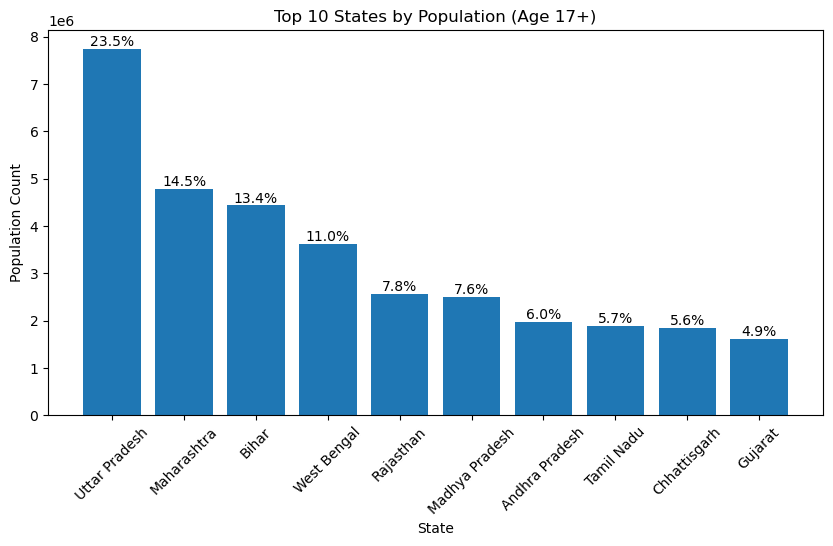

In [105]:
top10_17_ = df_17_demo.head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(
    top10_17_["state_clean"],
    top10_17_["demo_age_17_"])

plt.xlabel("State")
plt.ylabel("Population Count")
plt.title("Top 10 States by Population (Age 17+)")
plt.xticks(rotation=45)

total_17 = top10_17_["demo_age_17_"].sum()

for bar, value in zip(bars, top10_17_["demo_age_17_"]):
    pct = (value / total_17) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom")
plt.show()

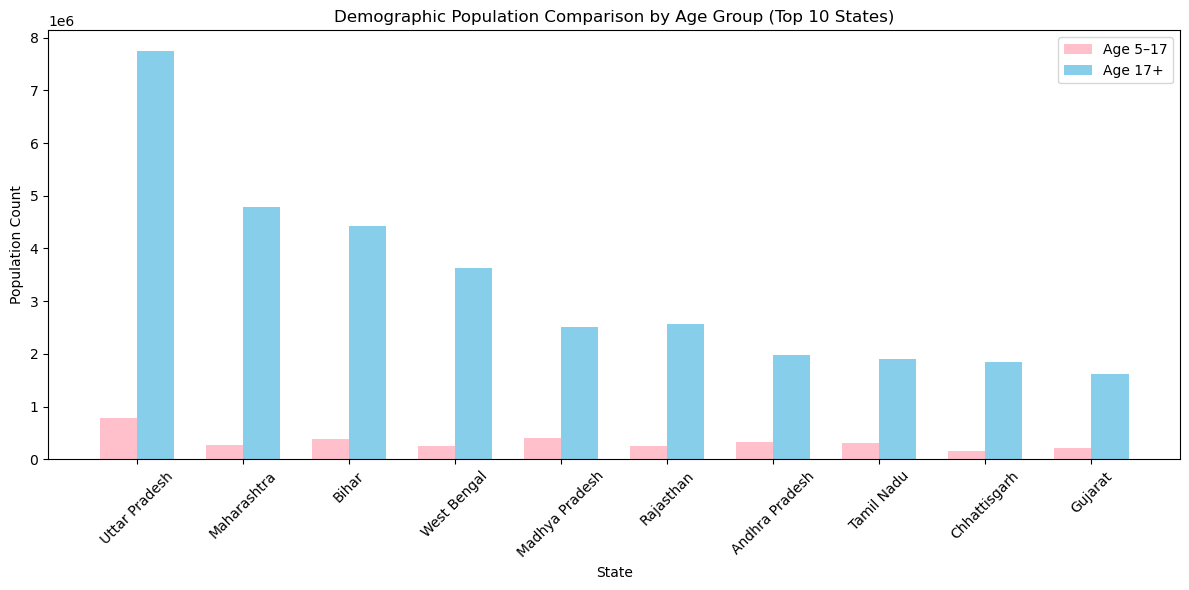

In [106]:
top10_demo_states = demo_state_summary.sort_values(
    "total_population", ascending=False).head(10)

states = top10_demo_states["state_clean"]
x = np.arange(len(states))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    top10_demo_states["demo_age_5_17"],
    width,
    label="Age 5–17",
    color="pink")

plt.bar(
    x + width/2,
    top10_demo_states["demo_age_17_"],
    width,
    label="Age 17+",
    color="skyblue")

plt.xticks(x, states, rotation=45)
plt.xlabel("State")
plt.ylabel("Population Count")
plt.title("Demographic Population Comparison by Age Group (Top 10 States)")
plt.legend()

plt.tight_layout()
plt.show()

In [107]:
age_stats = df[["age_0_5", "age_5_17", "age_18_greater"]].describe()
age_stats

,age_0_5,age_5_17,age_18_greater
count,1.006029e+06,1.006029e+06,1.006029e+06
mean,3.525709e+00,1.710074e+00,1.673441e-01
std,1.753851e+01,1.436963e+01,3.220525e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,0.000000e+00
75%,3.000000e+00,1.000000e+00,0.000000e+00
max,2.688000e+03,1.812000e+03,8.550000e+02


In [108]:
skewness = df[["age_0_5", "age_5_17", "age_18_greater"]].skew()
skewness

age_0_5           43.920908
age_5_17          41.900009
age_18_greater    87.854694
dtype: float64

In [109]:
kurtosis = df[["age_0_5", "age_5_17", "age_18_greater"]].kurtosis()
kurtosis

age_0_5            3105.542611
age_5_17           2477.050126
age_18_greater    12918.557085
dtype: float64

In [110]:
df["log_age_0_5"] = np.log1p(df["age_0_5"])
df["log_age_5_17"] = np.log1p(df["age_5_17"])
df["log_age_18+"] = np.log1p(df["age_18_greater"])

df[["log_age_0_5", "log_age_5_17", "log_age_18+"]].describe()

,log_age_0_5,log_age_5_17,log_age_18+
count,1.006029e+06,1.006029e+06,1.006029e+06
mean,1.082490e+00,5.035952e-01,4.353398e-02
std,7.207981e-01,6.988282e-01,2.610341e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.931472e-01,0.000000e+00,0.000000e+00
50%,1.098612e+00,0.000000e+00,0.000000e+00
75%,1.386294e+00,6.931472e-01,0.000000e+00
max,7.896925e+00,7.502738e+00,6.752270e+00


In [111]:
state_summary["cv_0_5"] = (
    state_summary["age_0_5"].std() / state_summary["age_0_5"].mean())

state_summary["cv_5_17"] = (
    state_summary["age_5_17"].std() / state_summary["age_5_17"].mean())

state_summary["cv_18+"] = (
    state_summary["age_18_greater"].std() / state_summary["age_18_greater"].mean())

state_summary[["cv_0_5", "cv_5_17", "cv_18+"]]

,cv_0_5,cv_5_17,cv_18+
0,1.275121,2.042753,1.693825
1,1.275121,2.042753,1.693825
2,1.275121,2.042753,1.693825
3,1.275121,2.042753,1.693825
4,1.275121,2.042753,1.693825
5,1.275121,2.042753,1.693825
6,1.275121,2.042753,1.693825
7,1.275121,2.042753,1.693825
8,1.275121,2.042753,1.693825
9,1.275121,2.042753,1.693825


In [112]:
corr_matrix = state_summary[
    ["age_0_5", "age_5_17", "age_18_greater"]].corr()

corr_matrix

,age_0_5,age_5_17,age_18_greater
age_0_5,1.000000,0.826226,0.480488
age_5_17,0.826226,1.000000,0.503293
age_18_greater,0.480488,0.503293,1.000000


In [113]:
state_summary["z_18+"] = zscore(state_summary["age_18_greater"])

extreme_states = state_summary[
    state_summary["z_18+"].abs() > 2]
extreme_states[["state_clean", "age_18_greater", "z_18+"]]

,state_clean,age_18_greater,z_18+
3,Assam,22877,2.410745
22,Meghalaya,35287,4.043171


In [114]:
district_summary["z_total"] = zscore(district_summary["total_enrolment"])

extreme_districts = district_summary[
    district_summary["z_total"].abs() > 3]
extreme_districts.sort_values("z_total", ascending=False)

,state_clean,district_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,z_total
356,Karnataka,Bengaluru Urban,38343,15318,7612,61273,7.855914
515,Maharashtra,Thane,29092,13629,967,43688,5.356584
154,Bihar,Sitamarhi,20679,18856,2697,42232,5.149645
789,Uttar Pradesh,Bahraich,14674,22360,2304,39338,4.738326
903,West Bengal,South 24 Parganas,28384,9427,330,38141,4.568198
896,West Bengal,North 24 Parganas,25920,8598,1862,36380,4.317910
894,West Bengal,Murshidabad,31442,4383,86,35911,4.251251
506,Maharashtra,Pune,24088,6536,1139,31763,3.661703
662,Rajasthan,Jaipur,21436,8976,734,31146,3.574009
856,Uttar Pradesh,Sitapur,16237,13869,748,30854,3.532508


In [115]:
demo_state_summary = (
    demo_df.groupby("state_clean")[["demo_age_5_17", "demo_age_17_"]]
    .sum().reset_index())

demo_state_summary["total_population"] = (
    demo_state_summary["demo_age_5_17"] +
    demo_state_summary["demo_age_17_"])

demo_state_summary.head()

,state_clean,demo_age_5_17,demo_age_17_,total_population
0,Andaman & Nicobar Islands,617,6629,7246
1,Andhra Pradesh,321148,1974434,2295582
2,Arunachal Pradesh,5783,30660,36443
3,Assam,84480,928098,1012578
4,Bihar,380023,4434327,4814350


In [116]:
final_state_df = pd.merge(
    state_summary,
    demo_state_summary,
    on="state_clean",
    how="inner")

final_state_df.head()

,state_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,pct_0_5,pct_5_17,pct_18+,cv_0_5,cv_5_17,cv_18+,z_18+,child_adult_ratio,demo_age_5_17,demo_age_17_,total_population
0,Andaman & Nicobar Islands,479,32,0,511,93.737769,6.262231,0.000000,1.275121,2.042753,1.693825,-0.598523,inf,617,6629,7246
1,Andhra Pradesh,112445,13746,1495,127686,88.063687,10.765472,1.170841,1.275121,2.042753,1.693825,-0.401869,84.408696,321148,1974434,2295582
2,Arunachal Pradesh,1957,2236,151,4344,45.050645,51.473297,3.476059,1.275121,2.042753,1.693825,-0.578660,27.768212,5783,30660,36443
3,Assam,141235,66085,22877,230197,61.353971,28.708020,9.938010,1.275121,2.042753,1.693825,2.410745,9.062377,84480,928098,1012578
4,Bihar,262875,334802,11908,609585,43.123600,54.922939,1.953460,1.275121,2.042753,1.693825,0.967870,50.191216,380023,4434327,4814350


In [117]:
final_state_df["coverage_5_17"] = (
    final_state_df["age_5_17"] /
    final_state_df["demo_age_5_17"])

final_state_df["coverage_17_plus"] = (
    final_state_df["age_18_greater"] /
    final_state_df["demo_age_17_"])

final_state_df[["state_clean", "coverage_5_17", "coverage_17_plus"]]

,state_clean,coverage_5_17,coverage_17_plus
0,Andaman & Nicobar Islands,0.051864,0.000000
1,Andhra Pradesh,0.042803,0.000757
2,Arunachal Pradesh,0.386651,0.004925
3,Assam,0.782256,0.024649
4,Bihar,0.881005,0.002685
5,Chandigarh,0.016066,0.000513
6,Chhattisgarh,0.113609,0.001085
7,Dadra & Nagar Haveli and Daman & Diu,0.130005,0.005058
8,Delhi,0.127017,0.002414
9,Goa,0.077557,0.005119


In [118]:
final_state_df = final_state_df.rename(
    columns={"demo_age_17_": "demo_age_17_plus"})

In [119]:
final_state_df["coverage_5_17"] = (
    final_state_df["age_5_17"] / final_state_df["demo_age_5_17"])

final_state_df["coverage_17_plus"] = (
    final_state_df["age_18_greater"] / final_state_df["demo_age_17_plus"])

final_state_df[["state_clean", "coverage_5_17", "coverage_17_plus"]].head()

,state_clean,coverage_5_17,coverage_17_plus
0,Andaman & Nicobar Islands,0.051864,0.000000
1,Andhra Pradesh,0.042803,0.000757
2,Arunachal Pradesh,0.386651,0.004925
3,Assam,0.782256,0.024649
4,Bihar,0.881005,0.002685


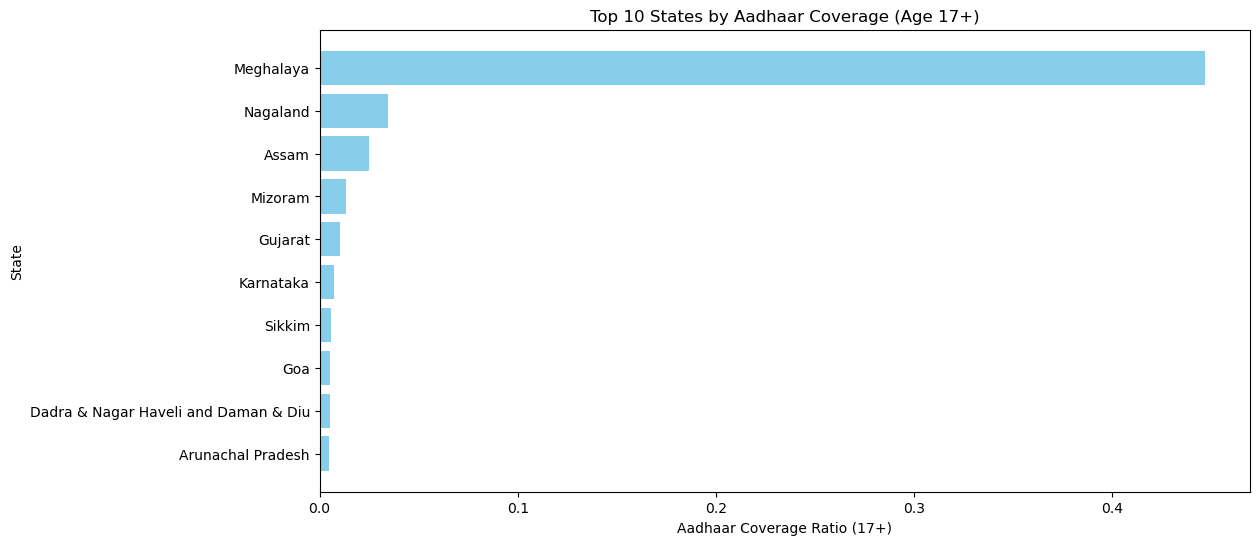

In [120]:
top10_coverage = (
    final_state_df.sort_values("coverage_17_plus", ascending=False).head(10))

plt.figure(figsize=(12,6))
plt.barh(
    top10_coverage["state_clean"],
    top10_coverage["coverage_17_plus"],
    color="skyblue")
plt.xlabel("Aadhaar Coverage Ratio (17+)")
plt.ylabel("State")
plt.title("Top 10 States by Aadhaar Coverage (Age 17+)")
plt.gca().invert_yaxis()
plt.show()

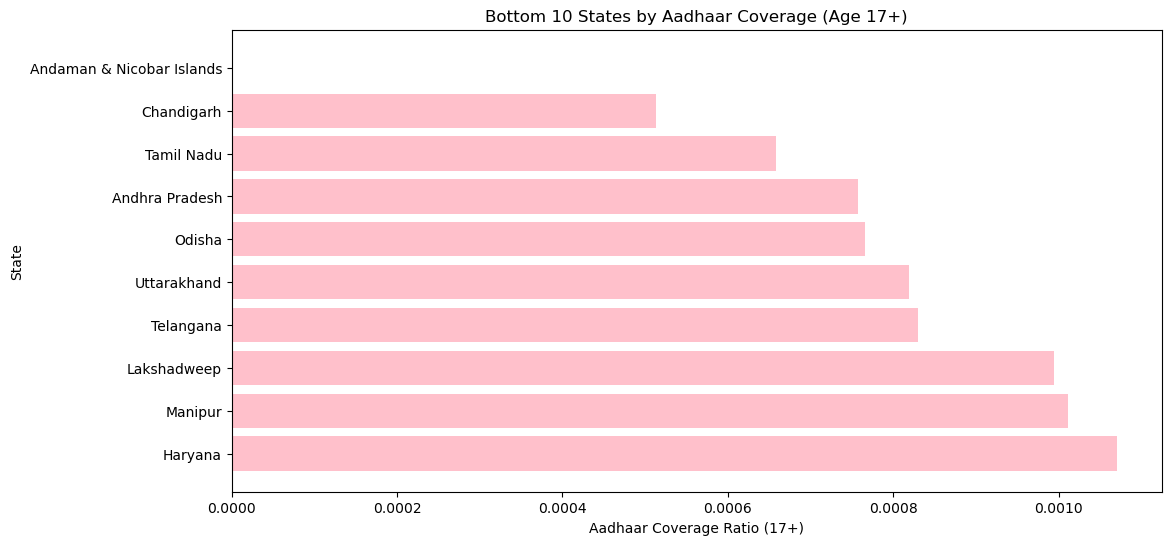

In [121]:
bottom10_coverage = (
    final_state_df.sort_values("coverage_17_plus", ascending=True).head(10))

plt.figure(figsize=(12,6))
plt.barh(
    bottom10_coverage["state_clean"],
    bottom10_coverage["coverage_17_plus"],
    color="pink")

plt.xlabel("Aadhaar Coverage Ratio (17+)")
plt.ylabel("State")
plt.title("Bottom 10 States by Aadhaar Coverage (Age 17+)")
plt.gca().invert_yaxis()
plt.show()

In [122]:
final_state_df["coverage_gap"] = (
    final_state_df["coverage_17_plus"] -
    final_state_df["coverage_5_17"])

final_state_df[
    ["state_clean", "coverage_5_17", "coverage_17_plus", "coverage_gap"]
].sort_values("coverage_gap", ascending=False).head(10)

,state_clean,coverage_5_17,coverage_17_plus,coverage_gap
5,Chandigarh,0.016066,0.000513,-0.015554
12,Himachal Pradesh,0.034030,0.001433,-0.032597
26,Puducherry,0.041525,0.001568,-0.039957
1,Andhra Pradesh,0.042803,0.000757,-0.042046
0,Andaman & Nicobar Islands,0.051864,0.000000,-0.051864
18,Lakshadweep,0.058824,0.000994,-0.057829
11,Haryana,0.065392,0.001071,-0.064321
9,Goa,0.077557,0.005119,-0.072439
17,Ladakh,0.096727,0.004128,-0.092599
31,Telangana,0.101152,0.000829,-0.100323


In [123]:
final_state_df[
    ["demo_age_5_17", "age_5_17",
     "demo_age_17_plus", "age_18_greater"]
].corr()

,demo_age_5_17,age_5_17,demo_age_17_plus,age_18_greater
demo_age_5_17,1.000000,0.829465,0.924697,0.367031
age_5_17,0.829465,1.000000,0.875531,0.499397
demo_age_17_plus,0.924697,0.875531,1.000000,0.394184
age_18_greater,0.367031,0.499397,0.394184,1.000000


In [124]:
final_district_df = pd.merge(
    district_summary,
    demo_district_summary,
    on=["state_clean", "district_clean"],
    how="inner")

final_district_df.head()

,state_clean,district_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,z_total,demo_age_5_17,demo_age_17_,total_population
0,Andaman & Nicobar Islands,Andamans,70,5,0,75,-0.842064,7,743,750
1,Andaman & Nicobar Islands,Nicobar,64,11,0,75,-0.842064,58,729,787
2,Andaman & Nicobar Islands,Nicobars,1,0,0,1,-0.852582,0,4,4
3,Andaman & Nicobar Islands,North And Middle Andaman,128,4,0,132,-0.833963,112,1897,2009
4,Andaman & Nicobar Islands,South Andaman,216,12,0,228,-0.820319,440,3256,3696


In [125]:
final_district_df["coverage_5_17"] = (
    final_district_df["age_5_17"] / final_district_df["demo_age_5_17"])

final_district_df["coverage_17_plus"] = (
    final_district_df["age_18_greater"] /
    final_district_df["demo_age_17_"])

final_district_df.replace([np.inf, -np.inf], np.nan, inplace=True)
final_district_df.dropna(
    subset=["coverage_5_17", "coverage_17_plus"],
    inplace=True)

final_district_df[
    ["state_clean", "district_clean", "coverage_5_17", "coverage_17_plus"]].head()

,state_clean,district_clean,coverage_5_17,coverage_17_plus
0,Andaman & Nicobar Islands,Andamans,0.714286,0.000000
1,Andaman & Nicobar Islands,Nicobar,0.189655,0.000000
3,Andaman & Nicobar Islands,North And Middle Andaman,0.035714,0.000000
4,Andaman & Nicobar Islands,South Andaman,0.027273,0.000000
5,Andhra Pradesh,Adilabad,0.108243,0.000037


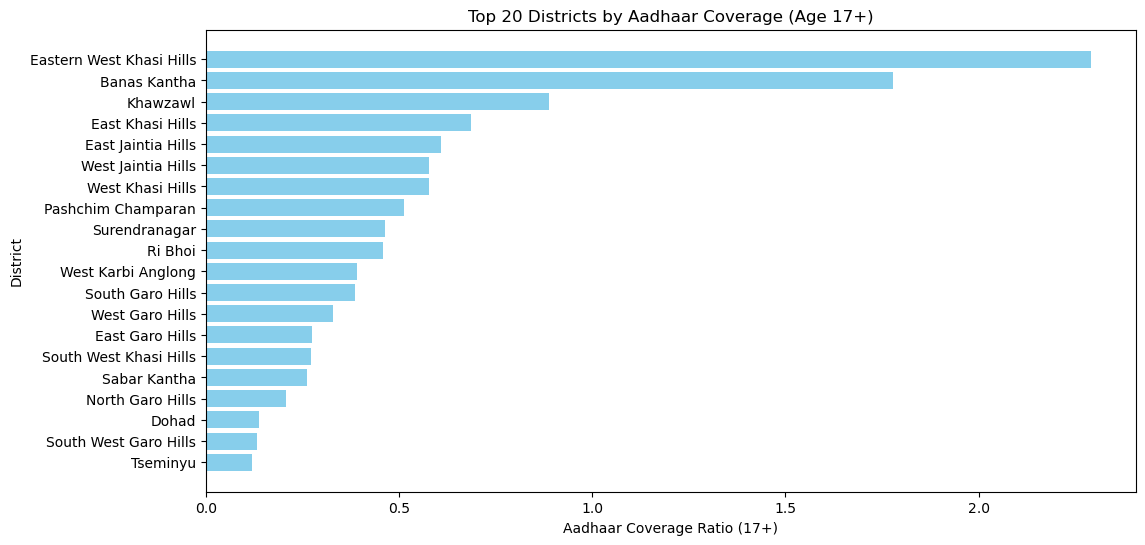

In [126]:
top20_district_coverage = (
    final_district_df.sort_values("coverage_17_plus", ascending=False).head(20))

plt.figure(figsize=(12,6))
plt.barh(
    top20_district_coverage["district_clean"],
    top20_district_coverage["coverage_17_plus"],
    color="skyblue")
plt.xlabel("Aadhaar Coverage Ratio (17+)")
plt.ylabel("District")
plt.title("Top 20 Districts by Aadhaar Coverage (Age 17+)")
plt.gca().invert_yaxis()
plt.show()

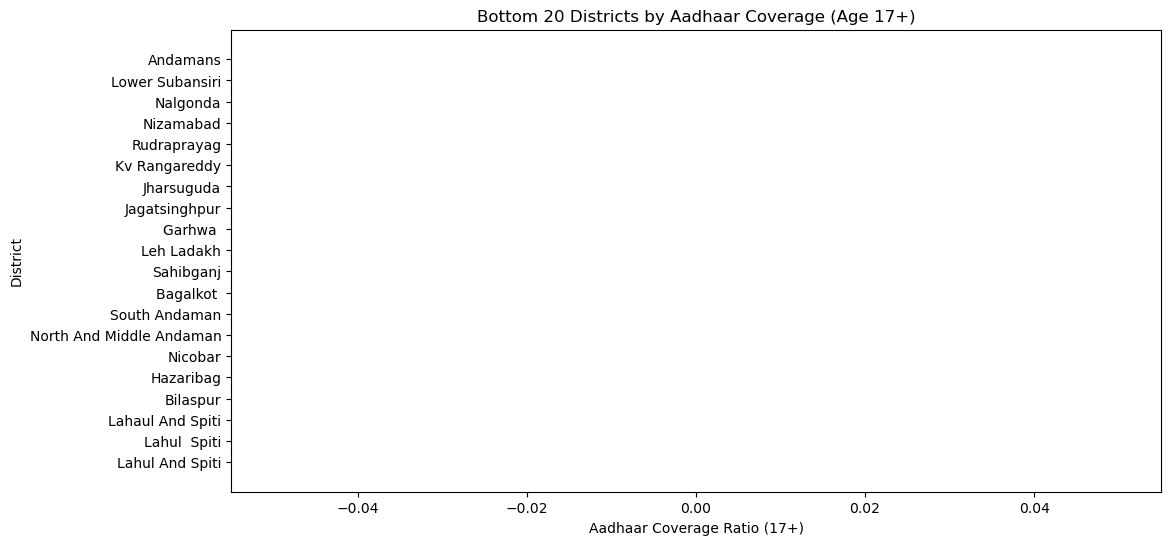

In [127]:
bottom20_district_coverage = (
    final_district_df.sort_values("coverage_17_plus", ascending=True).head(20))

plt.figure(figsize=(12,6))
plt.barh(
    bottom20_district_coverage["district_clean"],
    bottom20_district_coverage["coverage_17_plus"],
    color="pink")
plt.xlabel("Aadhaar Coverage Ratio (17+)")
plt.ylabel("District")
plt.title("Bottom 20 Districts by Aadhaar Coverage (Age 17+)")
plt.gca().invert_yaxis()
plt.show()

In [128]:
final_district_df["coverage_gap"] = (
    final_district_df["coverage_17_plus"] -final_district_df["coverage_5_17"])

final_district_df[
    ["state_clean", "district_clean","coverage_5_17", "coverage_17_plus", "coverage_gap"]].sort_values("coverage_gap", ascending=False).head(15)

,state_clean,district_clean,coverage_5_17,coverage_17_plus,coverage_gap
527,Mizoram,Khawzawl,0.875000,0.888889,0.013889
515,Meghalaya,Jaintia Hills,0.000000,0.000000,0.000000
27,Andhra Pradesh,Mahabubnagar,0.000000,0.000000,0.000000
617,Rajasthan,Balotra,0.000000,0.000000,0.000000
621,Rajasthan,Beawar,0.000000,0.000000,0.000000
650,Rajasthan,Salumbar,0.000000,0.000000,0.000000
526,Mizoram,Hnahthial,0.000000,0.000000,0.000000
632,Rajasthan,Didwanakuchaman,0.000000,0.000000,0.000000
272,Himachal Pradesh,Lahaul And Spiti,0.000000,0.000000,0.000000
343,Karnataka,Chamarajanagar,0.000000,0.000000,0.000000


In [129]:
final_district_df[
    ["demo_age_5_17", "age_5_17","demo_age_17_", "age_18_greater"]].corr()

,demo_age_5_17,age_5_17,demo_age_17_,age_18_greater
demo_age_5_17,1.000000,0.567762,0.867500,0.184867
age_5_17,0.567762,1.000000,0.660131,0.456978
demo_age_17_,0.867500,0.660131,1.000000,0.201851
age_18_greater,0.184867,0.456978,0.201851,1.000000


In [130]:
bio1 = pd.read_csv("api_data_aadhar_biometric_0_500000.csv")
bio2 = pd.read_csv("api_data_aadhar_biometric_500000_1000000.csv")
bio3 = pd.read_csv("api_data_aadhar_biometric_1000000_1500000.csv")
bio4 = pd.read_csv("api_data_aadhar_biometric_1500000_1861108.csv")

In [131]:
bio_df = pd.concat([bio1, bio2, bio3, bio4], ignore_index=True)
bio_df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [132]:
bio_df.shape

(1861108, 6)

In [133]:
bio_df.columns

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')

In [134]:
bio_df["state"].nunique()

57

In [135]:
bio_df["state"].unique()

array(['Haryana', 'Bihar', 'Jammu and Kashmir', 'Tamil Nadu',
       'Maharashtra', 'Gujarat', 'Odisha', 'West Bengal', 'Kerala',
       'Rajasthan', 'Punjab', 'Himachal Pradesh', 'Uttar Pradesh',
       'Assam', 'Uttarakhand', 'Madhya Pradesh', 'Karnataka',
       'Andhra Pradesh', 'Telangana', 'Goa', 'Nagaland', 'Jharkhand',
       'Delhi', 'Chhattisgarh', 'Meghalaya', 'Chandigarh', 'Orissa',
       'Puducherry', 'Pondicherry', 'Manipur', 'Sikkim', 'Tripura',
       'Mizoram', 'Arunachal Pradesh', 'Ladakh',
       'Dadra and Nagar Haveli and Daman and Diu', 'Daman and Diu',
       'Andaman and Nicobar Islands', 'Andaman & Nicobar Islands',
       'Dadra and Nagar Haveli', 'Lakshadweep', 'Daman & Diu',
       'Dadra & Nagar Haveli', 'Jammu & Kashmir', 'WESTBENGAL',
       'andhra pradesh', 'Westbengal', 'West  Bengal', 'WEST BENGAL',
       'West Bangal', 'ODISHA', 'odisha', 'West bengal', 'west Bengal',
       'Uttaranchal', 'Chhatisgarh', 'Tamilnadu'], dtype=object)

In [136]:
bio_df["state_norm"] = ( bio_df["state"]
                        .astype(str).str.strip().str.lower()
                        .str.replace(r"\s+", " ", regex=True))

In [137]:
state_clean_map = {
    "andhra pradesh": "Andhra Pradesh",
    "arunachal pradesh": "Arunachal Pradesh",
    "assam": "Assam",
    "bihar": "Bihar",

    "chhattisgarh": "Chhattisgarh",
    "chhatisgarh": "Chhattisgarh",

    "goa": "Goa",
    "gujarat": "Gujarat",
    "haryana": "Haryana",
    "himachal pradesh": "Himachal Pradesh",
    "jharkhand": "Jharkhand",
    "karnataka": "Karnataka",
    "kerala": "Kerala",
    "madhya pradesh": "Madhya Pradesh",
    "maharashtra": "Maharashtra",
    "manipur": "Manipur",
    "meghalaya": "Meghalaya",
    "mizoram": "Mizoram",
    "nagaland": "Nagaland",

    "odisha": "Odisha",
    "orissa": "Odisha",

    "punjab": "Punjab",
    "rajasthan": "Rajasthan",
    "sikkim": "Sikkim",
    "tamil nadu": "Tamil Nadu",
    "tamilnadu": "Tamil Nadu",

    "telangana": "Telangana",
    "tripura": "Tripura",

    "uttar pradesh": "Uttar Pradesh",
    "uttarakhand": "Uttarakhand",
    "uttaranchal": "Uttarakhand",

    "west bengal": "West Bengal",
    "westbengal": "West Bengal",
    "west  bengal": "West Bengal",
    "west bangal": "West Bengal",
    "west bengli": "West Bengal",

    "delhi": "Delhi",
    "chandigarh": "Chandigarh",
    "ladakh": "Ladakh",
    "lakshadweep": "Lakshadweep",

    "jammu and kashmir": "Jammu & Kashmir",
    "jammu & kashmir": "Jammu & Kashmir",

    "puducherry": "Puducherry",
    "pondicherry": "Puducherry",

    "andaman & nicobar islands": "Andaman & Nicobar Islands",
    "andaman and nicobar islands": "Andaman & Nicobar Islands",

    "daman and diu": "Dadra & Nagar Haveli and Daman & Diu",
    "daman & diu": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra and nagar haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra & nagar haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "dadra and nagar haveli and daman and diu":
        "Dadra & Nagar Haveli and Daman & Diu"
}

In [138]:
bio_df["state_clean"] = bio_df["state_norm"].replace(state_clean_map)

In [139]:
bio_df = bio_df[bio_df["state_clean"].notna()]

In [140]:
bio_df["state_clean"].nunique() 

36

In [141]:
bio_df["state_clean"].unique()

array(['Haryana', 'Bihar', 'Jammu & Kashmir', 'Tamil Nadu', 'Maharashtra',
       'Gujarat', 'Odisha', 'West Bengal', 'Kerala', 'Rajasthan',
       'Punjab', 'Himachal Pradesh', 'Uttar Pradesh', 'Assam',
       'Uttarakhand', 'Madhya Pradesh', 'Karnataka', 'Andhra Pradesh',
       'Telangana', 'Goa', 'Nagaland', 'Jharkhand', 'Delhi',
       'Chhattisgarh', 'Meghalaya', 'Chandigarh', 'Puducherry', 'Manipur',
       'Sikkim', 'Tripura', 'Mizoram', 'Arunachal Pradesh', 'Ladakh',
       'Dadra & Nagar Haveli and Daman & Diu',
       'Andaman & Nicobar Islands', 'Lakshadweep'], dtype=object)

In [142]:
bio_df["district_norm"] = (
    bio_df["district"].astype(str).str.strip()
    .str.lower()
    .str.replace(r"\s+", " ", regex=True))

In [143]:
district_clean_map = {
    "100000": "Unknown",
    "?": "Unknown",
    "akhera": "Akhera",
    "angul": "Angul",
    "anugal": "Angul",
    "anugul": "Angul",
    "anugul *": "Angul",
    "anugul  *": "Angul",
    "aurangabad(bh)": "Aurangabad",
    "auraiya *": "Auraiya",
    "bagalkot *": "Bagalkot",
    "baghpat *": "Baghpat",
    "balianta": "Khordha",
    "bally jagachha": "Howrah",
    "bandipur": "Bandipore",
    "bengaluru": "Bengaluru Urban",
    "bengaluru south": "Bengaluru Urban",
    "bangalore": "Bengaluru Urban",
    "bangalore rural": "Bengaluru Rural",
    "belgaum": "Belagavi",
    "bhadrak(r)": "Bhadrak",
    "bicholim": "North Goa",
    "bijapur": "Vijayapura",
    "bijapur(kar)": "Vijayapura",
    "bokaro *": "Bokaro",
    "burdwan": "Bardhaman",
    "chamarajanagar *": "Chamarajanagar",
    "chamrajnagar": "Chamarajanagar",
    "chandauli *": "Chandauli",
    "chitrakoot *": "Chitrakoot",
    "chittoor": "Chittoor",
    "coochbehar": "Cooch Behar",
    "dadra & nagar haveli": "Dadra & Nagar Haveli",
    "dadra and nagar haveli": "Dadra & Nagar Haveli",
    "deeg": "Deeg",
    "deeg\xa0": "Deeg",
    "dhalai *": "Dhalai",
    "dhalai  *": "Dhalai",
    "dist : thane": "Thane",
    "domjur": "Howrah",
    "east midnapore": "Purba Medinipur",
    "east midnapur": "Purba Medinipur",
    "faizabad": "Ayodhya",
    "gadag *": "Gadag",
    "garhwa *": "Garhwa",
    "gautam buddha nagar *": "Gautam Buddha Nagar",
    "gondiya": "Gondia",
    "gondiya *": "Gondia",
    "gurgaon": "Gurugram",
    "gulbarga": "Kalaburagi",
    "harda *": "Harda",
    "haveri *": "Haveri",
    "hingoli *": "Hingoli",
    "hooghly": "Hooghly",
    "hugli": "Hooghly",
    "howrah": "Howrah",
    "hawrah": "Howrah",
    "jajapur": "Jajpur",
    "jajapur  *": "Jajpur",
    "jajpur": "Jajpur",
    "janjgir - champa": "Janjgir-Champa",
    "janjgir champa": "Janjgir-Champa",
    "janjgir-champa": "Janjgir-Champa",
    "jyotiba phule nagar": "Amroha",
    "jyotiba phule nagar *": "Amroha",
    "khordha  *": "Khordha",
    "kheri": "Lakhimpur Kheri",
    "lakhimpur": "Lakhimpur Kheri",
    "lahul & spiti": "Lahaul and Spiti",
    "lahul and spiti": "Lahaul and Spiti",
    "lahaul and spiti": "Lahaul and Spiti",
    "leh (ladakh)": "Leh",
    "mahoba *": "Mahoba",
    "manendragarhchirmiribharatpur": "Manendragarh-Chirmiri-Bharatpur",
    "manendragarh-chirmiri-bharatpur": "Manendragarh-Chirmiri-Bharatpur",
    "medchalâ\x88\x92malkajgiri": "Medchal-Malkajgiri",
    "medchal?malkajgiri": "Medchal-Malkajgiri",
    "medchal−malkajgiri": "Medchal-Malkajgiri",
    "medinipur": "Paschim Medinipur",
    "medinipur west": "Paschim Medinipur",
    "west medinipur": "Paschim Medinipur",
    "mohali": "S.A.S. Nagar",
    "s.a.s nagar(mohali)": "S.A.S. Nagar",
    "sas nagar (mohali)": "S.A.S. Nagar",
    "mohalla-manpur-ambagarh chowki": "Mohla-Manpur-Ambagarh Chouki",
    "mumbai( sub urban )": "Mumbai Suburban",
    "mysore": "Mysuru",
    "naihati anandabazar": "North 24 Parganas",
    "nandurbar *": "Nandurbar",
    "narsimhapur": "Narsinghpur",
    "north east": "North East Delhi",
    "osmanabad": "Dharashiv",
    "pondicherry": "Puducherry",
    "raigarh(mh)": "Raigad",
    "rangareddi": "Rangareddy",
    "sant ravidas nagar bhadohi": "Bhadohi",
    "seraikela-kharsawan": "Seraikela-Kharsawan",
    "shimoga": "Shivamogga",
    "south 24 pargana": "South 24 Parganas",
    "south 24 parganas": "South 24 Parganas",
    "south dumdum(m)": "North 24 Parganas",
    "south  twenty four parganas": "South 24 Parganas",
    "south twenty four parganas": "South 24 Parganas",
    "tiswadi": "North Goa",
    "tuticorin": "Thoothukkudi",
    "udham singh nagar *": "Udham Singh Nagar",
    "udupi *": "Udupi",
    "washim *": "Washim",
    "yadgir": "Yadgir"
}

bio_df["district_clean"] = bio_df["district_norm"].map(district_clean_map).fillna(bio_df["district_norm"].str.title())

In [144]:
bio_df["district_clean"] = bio_df["district_norm"].replace(state_clean_map)

In [145]:
bio_df = bio_df[bio_df["district_clean"].notna()]

In [146]:
bio_df["district"].nunique()

974

In [147]:
bio_df[["district", "district_clean"]].head()

,district,district_clean
0,Mahendragarh,mahendragarh
1,Madhepura,madhepura
2,Punch,punch
3,Bhojpur,bhojpur
4,Madurai,madurai


In [148]:
bio_df = bio_df[bio_df["district_clean"] != ""]

In [149]:
bio_df["district_clean"].nunique()

947

In [150]:
bio_state_summary = (
    bio_df.groupby("state_clean")[["bio_age_5_17", "bio_age_17_"]].sum().reset_index())

In [151]:
bio_state_summary["total_biometrics"] = (
    bio_state_summary["bio_age_5_17"]+ bio_state_summary["bio_age_17_"])

In [152]:
bio_state_summary.head()

,state_clean,bio_age_5_17,bio_age_17_,total_biometrics
0,Andaman & Nicobar Islands,11806,8892,20698
1,Andhra Pradesh,2241467,1473166,3714633
2,Arunachal Pradesh,42894,29500,72394
3,Assam,596624,386098,982722
4,Bihar,2208141,2689446,4897587


In [153]:
bio_stats = bio_df[["bio_age_5_17", "bio_age_17_"]].describe()
bio_stats

,bio_age_5_17,bio_age_17_
count,1.861108e+06,1.861108e+06
mean,1.839058e+01,1.909413e+01
std,8.370421e+01,8.806502e+01
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00
50%,3.000000e+00,4.000000e+00
75%,1.100000e+01,1.000000e+01
max,8.002000e+03,7.625000e+03


In [154]:
bio_skewness = bio_df[["bio_age_5_17", "bio_age_17_"]].skew()
bio_skewness

bio_age_5_17    19.330627
bio_age_17_     18.078189
dtype: float64

In [155]:
bio_kurtosis = bio_df[["bio_age_5_17", "bio_age_17_"]].kurtosis()
bio_kurtosis

bio_age_5_17    709.519768
bio_age_17_     609.143086
dtype: float64

In [156]:
bio_kurtosis = bio_df[["bio_age_5_17", "bio_age_17_"]].kurtosis()
bio_kurtosis

bio_age_5_17    709.519768
bio_age_17_     609.143086
dtype: float64

In [157]:
bio_df["log_bio_5_17"] = np.log1p(bio_df["bio_age_5_17"])
bio_df["log_bio_17+"] = np.log1p(bio_df["bio_age_17_"])

In [158]:
bio_log_stats = bio_df[["log_bio_5_17", "log_bio_17+"]].describe()
bio_log_stats

,log_bio_5_17,log_bio_17+
count,1.861108e+06,1.861108e+06
mean,1.697811e+00,1.754351e+00
std,1.311081e+00,1.256997e+00
min,0.000000e+00,0.000000e+00
25%,6.931472e-01,6.931472e-01
50%,1.386294e+00,1.609438e+00
75%,2.484907e+00,2.397895e+00
max,8.987572e+00,8.939319e+00


In [159]:
bio_log_skew = bio_df[["log_bio_5_17", "log_bio_17+"]].skew()
bio_log_skew

log_bio_5_17    0.895871
log_bio_17+     1.028001
dtype: float64

In [160]:
bio_log_kurt = bio_df[["log_bio_5_17", "log_bio_17+"]].kurtosis()
bio_log_kurt

log_bio_5_17    0.915553
log_bio_17+     1.485733
dtype: float64

C:\Users\aksha\AppData\Local\Temp\ipykernel_36404\122480515.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


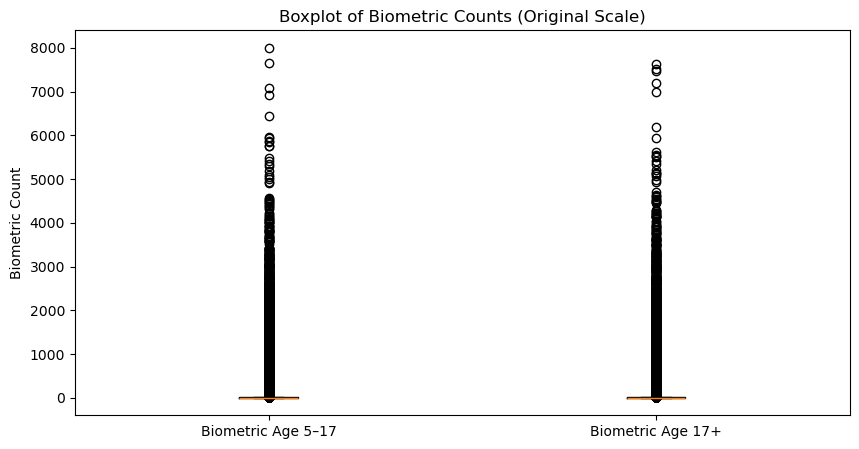

In [161]:
plt.figure(figsize=(10,5))
plt.boxplot(
    [bio_df["bio_age_5_17"], bio_df["bio_age_17_"]],
    labels=["Biometric Age 5–17", "Biometric Age 17+"],
    showfliers=True
)
plt.title("Boxplot of Biometric Counts (Original Scale)")
plt.ylabel("Biometric Count")
plt.show()

C:\Users\aksha\AppData\Local\Temp\ipykernel_36404\3191296400.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


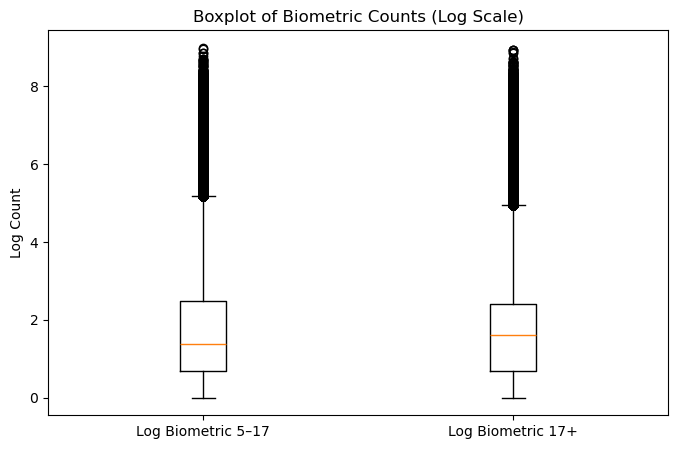

In [162]:
plt.figure(figsize=(8,5))
plt.boxplot(
    [bio_df["log_bio_5_17"], bio_df["log_bio_17+"]],
    labels=["Log Biometric 5–17", "Log Biometric 17+"],
    showfliers=True
)
plt.title("Boxplot of Biometric Counts (Log Scale)")
plt.ylabel("Log Count")
plt.show()


In [163]:
bio_state_summary["cv_bio_5_17"] = (
    bio_state_summary["bio_age_5_17"].std() /
    bio_state_summary["bio_age_5_17"].mean()
)

bio_state_summary["cv_bio_17+"] = (
    bio_state_summary["bio_age_17_"].std() /
    bio_state_summary["bio_age_17_"].mean()
)

bio_state_summary[["state_clean", "cv_bio_5_17", "cv_bio_17+"]].head()

,state_clean,cv_bio_5_17,cv_bio_17+
0,Andaman & Nicobar Islands,1.364404,1.250135
1,Andhra Pradesh,1.364404,1.250135
2,Arunachal Pradesh,1.364404,1.250135
3,Assam,1.364404,1.250135
4,Bihar,1.364404,1.250135


In [164]:
bio_corr = bio_state_summary[
    ["bio_age_5_17", "bio_age_17_"]].corr()

bio_corr

,bio_age_5_17,bio_age_17_
bio_age_5_17,1.000000,0.862823
bio_age_17_,0.862823,1.000000


In [165]:
from scipy.stats import zscore

bio_state_summary["z_bio_17+"] = zscore(
    bio_state_summary["bio_age_17_"])

extreme_bio_states = bio_state_summary[
    bio_state_summary["z_bio_17+"].abs() > 2]

extreme_bio_states[
    ["state_clean", "bio_age_17_", "z_bio_17+"]].sort_values("z_bio_17+", ascending=False)

,state_clean,bio_age_17_,z_bio_17+
20,Maharashtra,5713427,3.884307


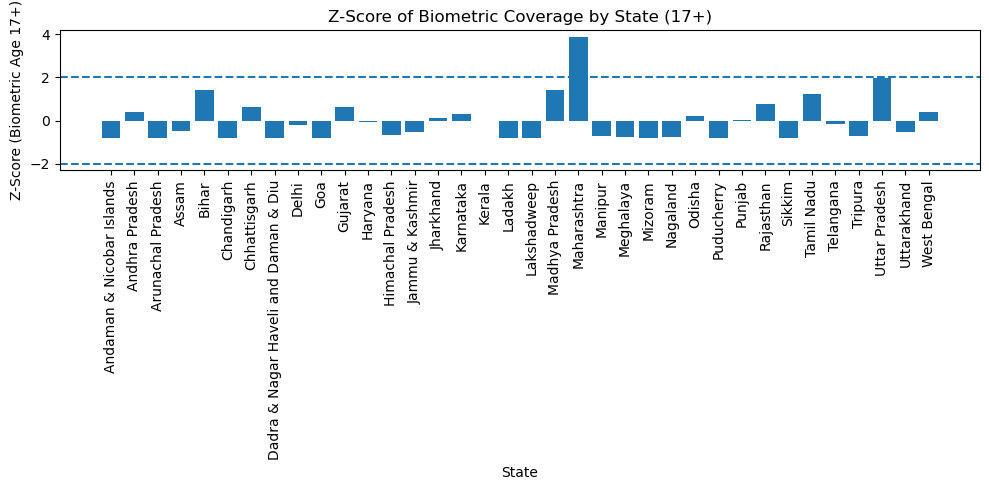

In [166]:
plt.figure(figsize=(10,5))
plt.bar(
    bio_state_summary["state_clean"],
    bio_state_summary["z_bio_17+"]
)

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Z-Score (Biometric Age 17+)")
plt.title("Z-Score of Biometric Coverage by State (17+)")
plt.tight_layout()
plt.show()

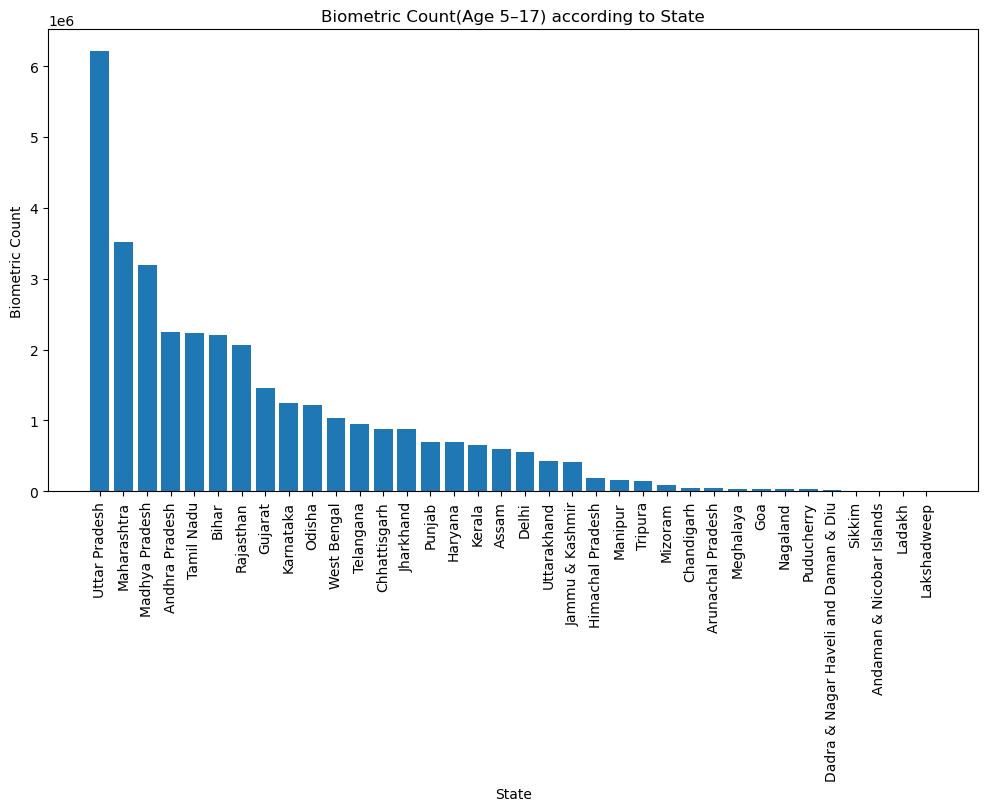

In [167]:
df_5_17 = bio_state_summary.sort_values("bio_age_5_17", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_5_17["state_clean"], df_5_17["bio_age_5_17"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Biometric Count")
plt.title("Biometric Count(Age 5–17) according to State")
plt.show()

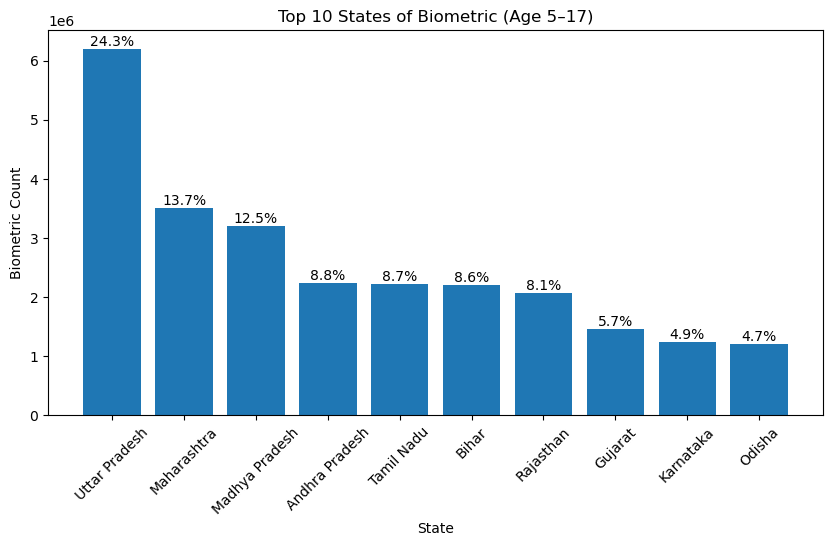

In [168]:
top10_5_17 = bio_state_summary.sort_values(
    "bio_age_5_17", ascending=False).head(10)

top10_5_17["percentage"] = (
    top10_5_17["bio_age_5_17"] /
    top10_5_17["bio_age_5_17"].sum())* 100

plt.figure(figsize=(10,5))
bars = plt.bar(
    top10_5_17["state_clean"],
    top10_5_17["bio_age_5_17"])

plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Biometric Count")
plt.title("Top 10 States of Biometric (Age 5–17)")

for bar, pct in zip(bars, top10_5_17["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom")
plt.show()

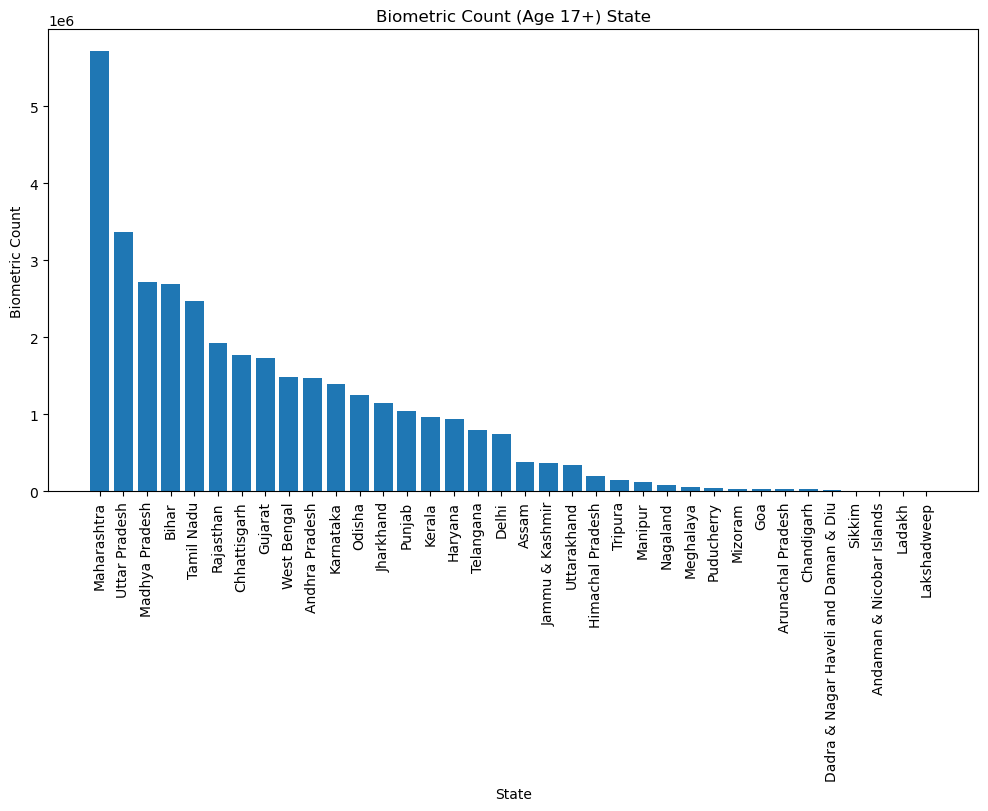

In [169]:
df_17 = bio_state_summary.sort_values("bio_age_17_", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_17["state_clean"], df_17["bio_age_17_"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Biometric Count")
plt.title("Biometric Count (Age 17+) State")
plt.show()

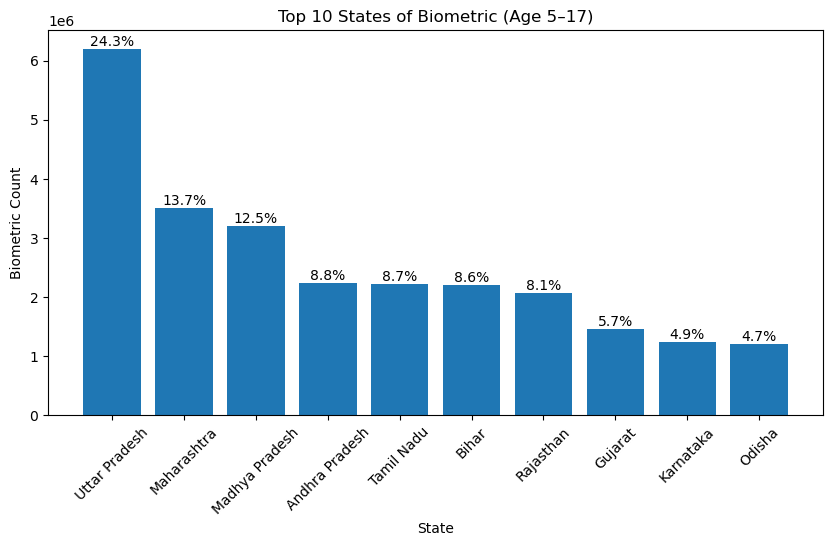

In [170]:
top10_5_17 = bio_state_summary.sort_values(
    "bio_age_5_17", ascending=False).head(10)

top10_5_17["percentage"] = (
    top10_5_17["bio_age_5_17"] / top10_5_17["bio_age_5_17"].sum())* 100

plt.figure(figsize=(10,5))
bars = plt.bar(
    top10_5_17["state_clean"],
    top10_5_17["bio_age_5_17"])

plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Biometric Count")
plt.title("Top 10 States of Biometric (Age 5–17)")

for bar, pct in zip(bars, top10_5_17["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom")
plt.show()

In [171]:
bio_state_summary["pct_5_17"] = (
    bio_state_summary["bio_age_5_17"]/ bio_state_summary["total_biometrics"]) * 100

bio_state_summary["pct_17+"] = (
    bio_state_summary["bio_age_17_"]/ bio_state_summary["total_biometrics"]) * 100

In [172]:
bio_state_summary[
    ["state_clean", "pct_5_17", "pct_17+"]].sort_values("pct_17+", ascending=False)

,state_clean,pct_5_17,pct_17+
24,Nagaland,29.710839,70.289161
6,Chhattisgarh,33.395388,66.604612
20,Maharashtra,38.073478,61.926522
26,Puducherry,38.687990,61.312010
27,Punjab,40.246518,59.753482
16,Kerala,40.251409,59.748591
35,West Bengal,41.214615,58.785385
7,Dadra & Nagar Haveli and Daman & Diu,41.667516,58.332484
22,Meghalaya,41.689681,58.310319
11,Haryana,42.414339,57.585661


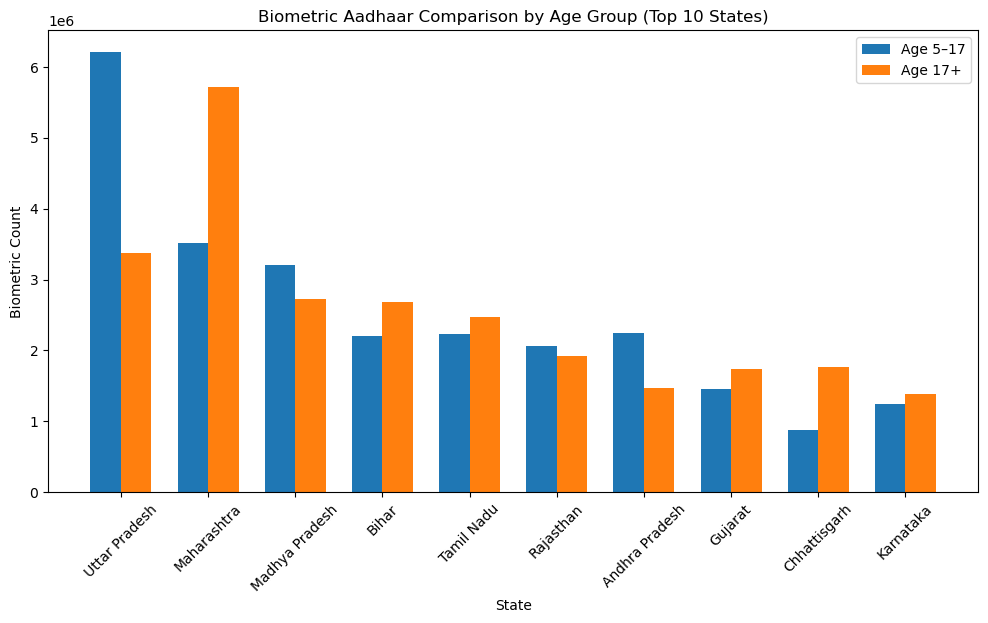

In [173]:
import numpy as np

top10_states = bio_state_summary.sort_values(
    "total_biometrics", ascending=False).head(10)

x = np.arange(len(top10_states))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    top10_states["bio_age_5_17"],
    width,
    label="Age 5–17")

plt.bar(
    x + width/2,
    top10_states["bio_age_17_"],
    width,
    label="Age 17+")

plt.xticks(x, top10_states["state_clean"], rotation=45)
plt.xlabel("State")
plt.ylabel("Biometric Count")
plt.title("Biometric Aadhaar Comparison by Age Group (Top 10 States)")
plt.legend()
plt.show()

In [174]:
merged_df = pd.merge(
    state_summary,
    demo_state_summary,
    on="state_clean",
    how="inner")
merged_df = pd.merge(
    merged_df,
    bio_state_summary,
    on="state_clean",
    how="inner")
merged_df.head()

,state_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,pct_0_5,pct_5_17_x,pct_18+,cv_0_5,cv_5_17,...,demo_age_17_,total_population,bio_age_5_17,bio_age_17_,total_biometrics,cv_bio_5_17,cv_bio_17+,z_bio_17+,pct_5_17_y,pct_17+
0,Andaman & Nicobar Islands,479,32,0,511,93.737769,6.262231,0.000000,1.275121,2.042753,...,6629,7246,11806,8892,20698,1.364404,1.250135,-0.803953,57.039327,42.960673
1,Andhra Pradesh,112445,13746,1495,127686,88.063687,10.765472,1.170841,1.275121,2.042753,...,1974434,2295582,2241467,1473166,3714633,1.364404,1.250135,0.399458,60.341547,39.658453
2,Arunachal Pradesh,1957,2236,151,4344,45.050645,51.473297,3.476059,1.275121,2.042753,...,30660,36443,42894,29500,72394,1.364404,1.250135,-0.787016,59.250767,40.749233
3,Assam,141235,66085,22877,230197,61.353971,28.708020,9.938010,1.275121,2.042753,...,928098,1012578,596624,386098,982722,1.364404,1.250135,-0.493947,60.711371,39.288629
4,Bihar,262875,334802,11908,609585,43.123600,54.922939,1.953460,1.275121,2.042753,...,4434327,4814350,2208141,2689446,4897587,1.364404,1.250135,1.399055,45.086305,54.913695


In [175]:
merged_df["aadhaar_coverage_ratio"] = (
    merged_df["total_enrolment"] / merged_df["total_population"])

merged_df["biometric_per_enrolment"] = (
    merged_df["total_biometrics"] / merged_df["total_enrolment"])

merged_df["child_enrolment_pct"] = (
    (merged_df["age_0_5"] + merged_df["age_5_17"]) /
    merged_df["total_enrolment"]) * 100

merged_df["adult_biometric_pct"] = (
    merged_df["bio_age_17_"] / merged_df["total_biometrics"]) * 100

merged_df.head()

,state_clean,age_0_5,age_5_17,age_18_greater,total_enrolment,pct_0_5,pct_5_17_x,pct_18+,cv_0_5,cv_5_17,...,total_biometrics,cv_bio_5_17,cv_bio_17+,z_bio_17+,pct_5_17_y,pct_17+,aadhaar_coverage_ratio,biometric_per_enrolment,child_enrolment_pct,adult_biometric_pct
0,Andaman & Nicobar Islands,479,32,0,511,93.737769,6.262231,0.000000,1.275121,2.042753,...,20698,1.364404,1.250135,-0.803953,57.039327,42.960673,0.070522,40.504892,100.000000,42.960673
1,Andhra Pradesh,112445,13746,1495,127686,88.063687,10.765472,1.170841,1.275121,2.042753,...,3714633,1.364404,1.250135,0.399458,60.341547,39.658453,0.055622,29.091936,98.829159,39.658453
2,Arunachal Pradesh,1957,2236,151,4344,45.050645,51.473297,3.476059,1.275121,2.042753,...,72394,1.364404,1.250135,-0.787016,59.250767,40.749233,0.119200,16.665285,96.523941,40.749233
3,Assam,141235,66085,22877,230197,61.353971,28.708020,9.938010,1.275121,2.042753,...,982722,1.364404,1.250135,-0.493947,60.711371,39.288629,0.227338,4.269048,90.061990,39.288629
4,Bihar,262875,334802,11908,609585,43.123600,54.922939,1.953460,1.275121,2.042753,...,4897587,1.364404,1.250135,1.399055,45.086305,54.913695,0.126618,8.034297,98.046540,54.913695


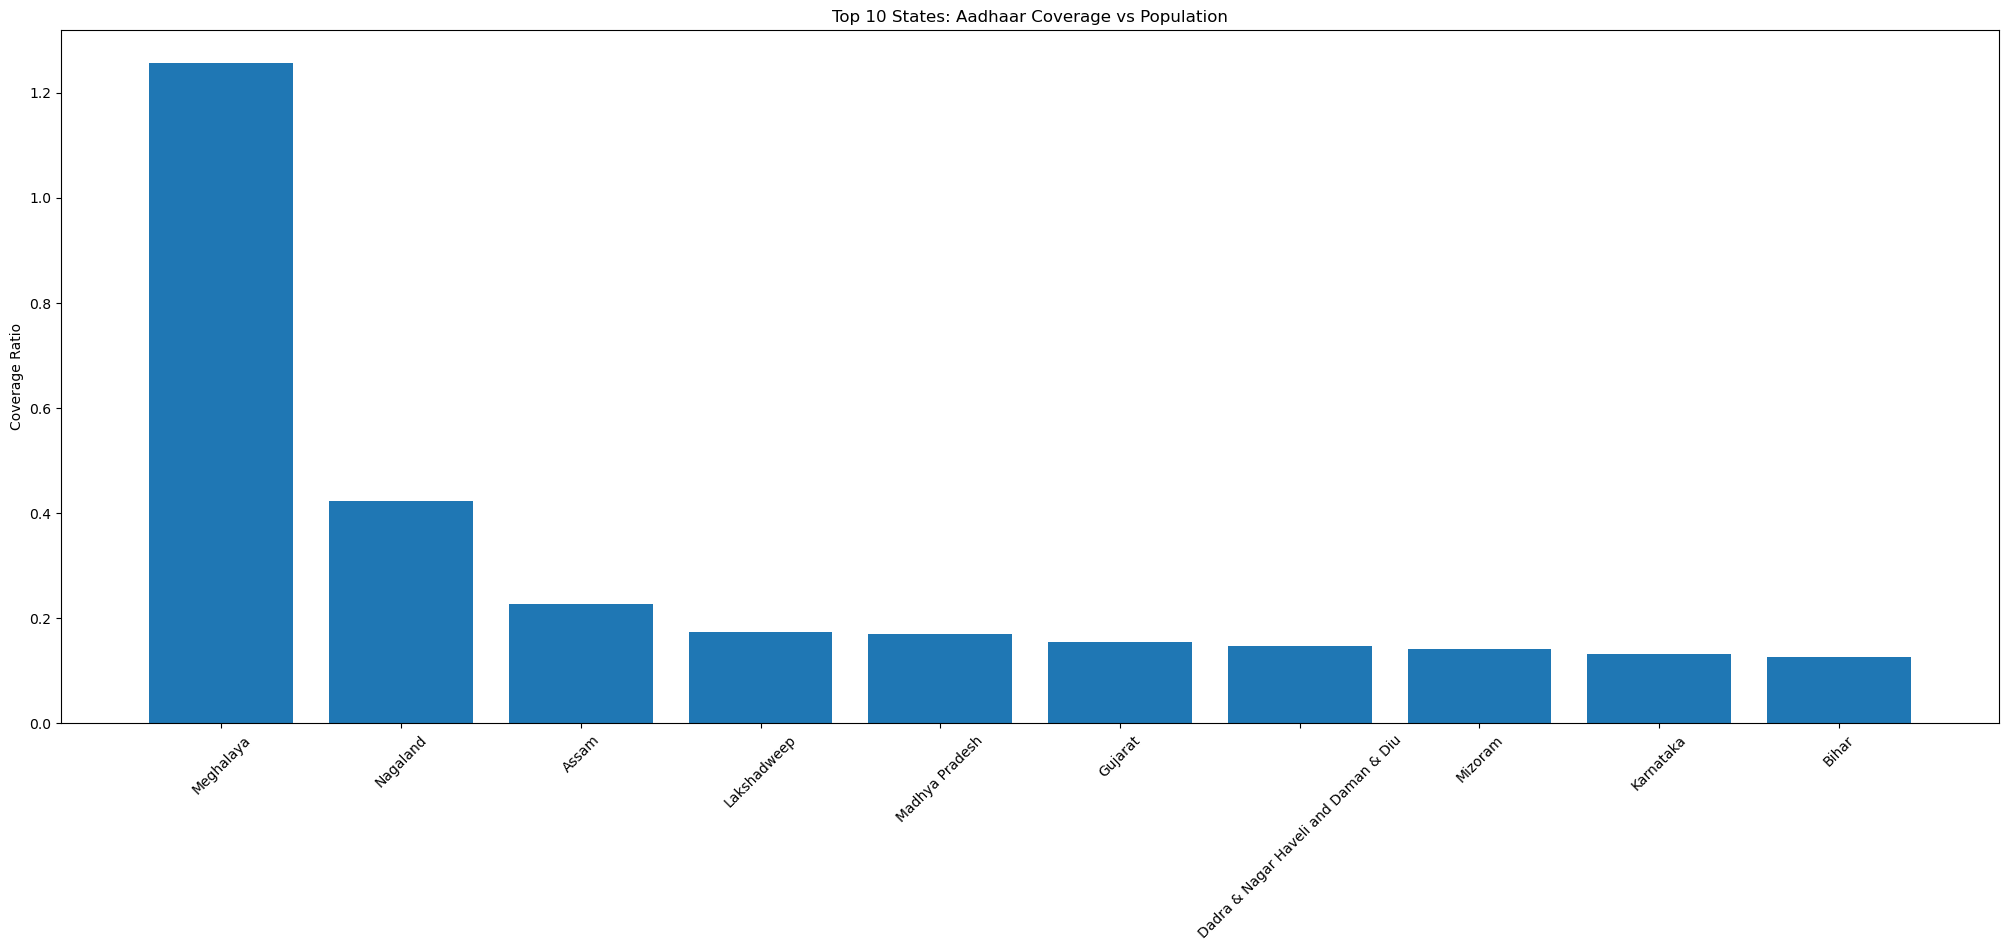

In [176]:
top_coverage = merged_df.sort_values(
    "aadhaar_coverage_ratio", ascending=False).head(10)

plt.figure(figsize=(25,9))
plt.bar(top_coverage["state_clean"],
        top_coverage["aadhaar_coverage_ratio"])
plt.xticks(rotation=45)
plt.ylabel("Coverage Ratio")
plt.title("Top 10 States: Aadhaar Coverage vs Population")
plt.show()

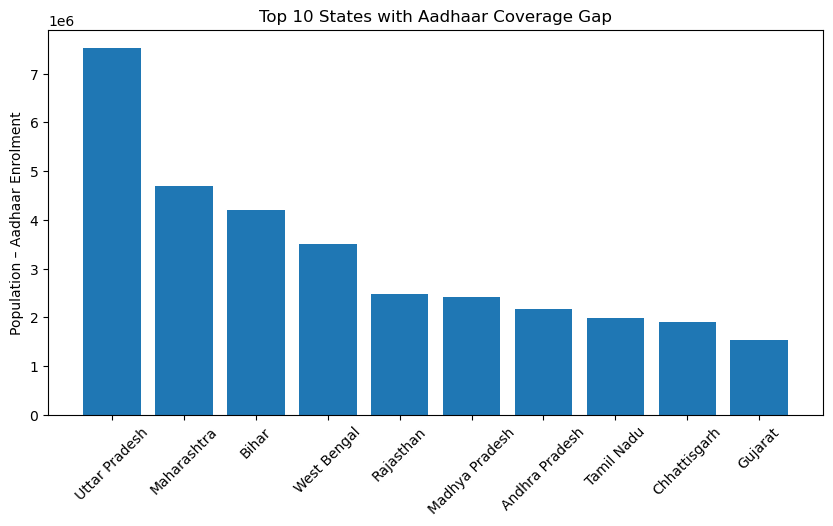

In [177]:
merged_df["enrolment_gap"] = (
    merged_df["total_population"] - merged_df["total_enrolment"])

gap_states = merged_df.sort_values(
    "enrolment_gap", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(gap_states["state_clean"],
        gap_states["enrolment_gap"])
plt.xticks(rotation=45)
plt.ylabel("Population – Aadhaar Enrolment")
plt.title("Top 10 States with Aadhaar Coverage Gap")
plt.show()

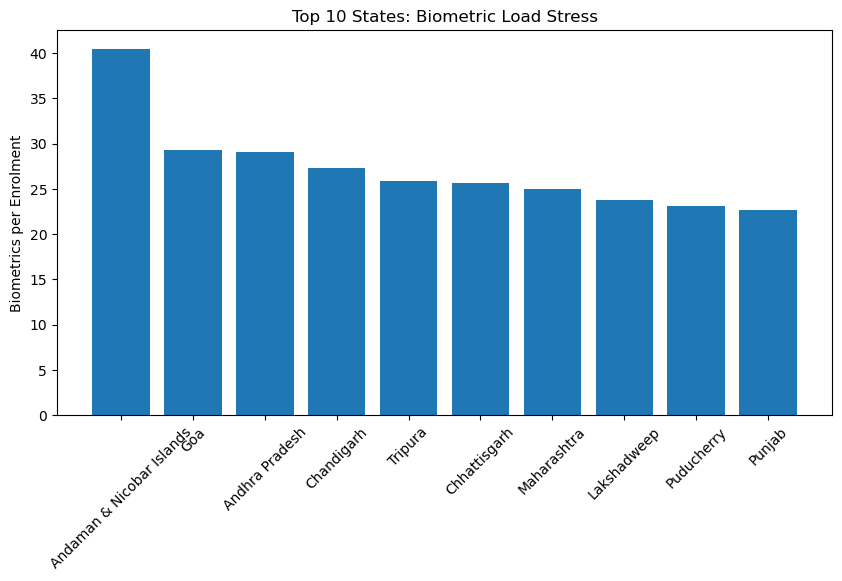

In [178]:
stress_states = merged_df.sort_values(
    "biometric_per_enrolment", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(stress_states["state_clean"],
        stress_states["biometric_per_enrolment"])
plt.xticks(rotation=45)
plt.ylabel("Biometrics per Enrolment")
plt.title("Top 10 States: Biometric Load Stress")
plt.show()

In [179]:
corr_cols = [
    "total_enrolment",
    "total_population",
    "total_biometrics",
    "aadhaar_coverage_ratio",
    "biometric_per_enrolment"]

merged_df[corr_cols].corr()

,total_enrolment,total_population,total_biometrics,aadhaar_coverage_ratio,biometric_per_enrolment
total_enrolment,1.000000,0.951099,0.869615,-0.009888,-0.413873
total_population,0.951099,1.000000,0.930125,-0.135749,-0.269421
total_biometrics,0.869615,0.930125,1.000000,-0.145334,-0.146571
aadhaar_coverage_ratio,-0.009888,-0.135749,-0.145334,1.000000,-0.481915
biometric_per_enrolment,-0.413873,-0.269421,-0.146571,-0.481915,1.000000
